In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings
warnings.filterwarnings('ignore')
sns.set(style="whitegrid")

## Load Data

In [2]:
try:
    base_dir = os.path.join(os.path.dirname(os.path.abspath(__file__)), "initial_data")
except NameError:
    base_dir = os.path.join(os.getcwd(), "..", "initial_data")
    base_dir = os.path.abspath(base_dir)

print("Looking for data in:", base_dir)
print("Path exists:", os.path.exists(base_dir))

# load f7
function_folder = os.path.join(base_dir, "function_7")
inputs = np.load(os.path.join(function_folder, "initial_inputs.npy"))
outputs = np.load(os.path.join(function_folder, "initial_outputs.npy"))

# reshape if needed
if inputs.ndim == 1:
    inputs = inputs.reshape(-1, 1)
if outputs.ndim == 1:
    outputs = outputs.reshape(-1, 1)

# create dataframe
input_cols = [f"X{j+1}" for j in range(inputs.shape[1])]
output_cols = [f"y{j+1}" for j in range(outputs.shape[1])]

df_f7 = pd.DataFrame(
    np.concatenate([inputs, outputs], axis=1),
    columns=input_cols + output_cols
)

print(f"Loaded function 7: shape = {df_f7.shape}, columns = {df_f7.columns.tolist()}")



Looking for data in: C:\Users\Hassa\OneDrive - Loughborough University\current\ML & AI\Capstone Project\initial_data
Path exists: True
Loaded function 7: shape = (30, 7), columns = ['X1', 'X2', 'X3', 'X4', 'X5', 'X6', 'y1']


In [3]:
week1_results = {"f7": ([0.799542, 0.949047, 0.887638, 0.265662, 0.631518, 0.349925], 0.026543407526137847)}

In [4]:
week2_results = {"f7": ([0.008500, 0.278800, 0.231600, 0.099300, 0.323000, 0.980800], 0.7653612109103147)}

In [5]:
week3_results = {"f7": ([0.000000, 0.189754, 0.123991, 0.253411, 0.406355, 0.251864], 0.4981320924641522)}

In [6]:
week4_results = {"f7": ([0.097366, 0.334928, 0.369818, 0.382418, 0.464971, 0.750762], 1.5985145628892428)}

In [7]:
week5_results = {"f7": ([0.053955, 0.757891, 0.608290, 0.473788, 0.364363, 0.971498], 0.32752252967109274)}

In [8]:
week6_results = {"f7": ([0.069772, 0.319669, 0.577421, 0.210909, 0.386068, 0.707262], 2.448290856114691)}

In [9]:
week7_results = {"f7": ([0.064462, 0.412641, 0.669514, 0.193009, 0.502173, 0.667338], 1.3516399930526517)}

In [10]:
week8_results = {"f7": ([0.186891, 0.934228, 0.522974, 0.187825, 0.066947, 0.841778], 0.13054782987236474)}

In [11]:
week9_results = {"f7": ([0.019978, 0.998379, 0.127323, 0.788041, 0.383133, 0.520111], 0.01764809003897648)}

In [12]:
week10_results = {"f7": ([0.125310, 0.292720, 0.563314, 0.153089, 0.354283, 0.706302], 2.55796551675835)}

In [13]:
week11_results = {"f7": ([0.044832, 0.301537, 0.610489, 0.251885, 0.351513, 0.697493], 2.5822487885107996)}

In [14]:
weekly_results = {
    "week1": week1_results,
    "week2": week2_results,
    "week3": week3_results,
    "week4": week4_results,
    "week5": week5_results,
    "week6": week6_results,
    "week7": week7_results,
    "week8": week8_results,
    "week9": week9_results,
    "week10": week10_results,
    "week11": week11_results,
}

output_col = output_cols[0]   # this gives "y1"

# add weekly results to df_f7

for week, results in weekly_results.items():
    
    if "f7" not in results:
        continue
    
    inputs, output = results["f7"]
    
    # convert to numpy arrays
    inputs = np.array(inputs).reshape(1, -1)
    output = np.array([output]).reshape(1, -1)
    
    # build dataframe row with the same columns as df_f7
    df_new_row = pd.DataFrame(
        np.concatenate([inputs, output], axis=1),
        columns=["X1", "X2", "X3", "X4", "X5", "X6", "y1"]
    )
    
    # append to df_f7
    df_f7 = pd.concat([df_f7, df_new_row], ignore_index=True)
    
    # remove duplicates
    df_f7 = df_f7.drop_duplicates(ignore_index=True)

print("updated f7 shape:", df_f7.shape)


updated f7 shape: (41, 7)


In [15]:
print(df_f7)

          X1        X2        X3        X4        X5        X6        y1
0   0.272624  0.324495  0.897109  0.832951  0.154063  0.795864  0.604433
1   0.543003  0.924694  0.341567  0.646486  0.718440  0.343133  0.562753
2   0.090832  0.661529  0.065931  0.258577  0.963453  0.640265  0.007503
3   0.118867  0.615055  0.905816  0.855300  0.413631  0.585236  0.061424
4   0.630218  0.838097  0.680013  0.731895  0.526737  0.348429  0.273047
5   0.764919  0.255883  0.609084  0.218079  0.322943  0.095794  0.083747
6   0.057896  0.491672  0.247422  0.218118  0.420428  0.730970  1.364968
7   0.195252  0.079227  0.554580  0.170567  0.014944  0.107032  0.092645
8   0.642303  0.836875  0.021793  0.101488  0.683071  0.692416  0.017870
9   0.789943  0.195545  0.575623  0.073659  0.259049  0.051100  0.033565
10  0.528497  0.457424  0.360096  0.362046  0.816891  0.637476  0.073516
11  0.722615  0.011813  0.063646  0.165173  0.079244  0.359952  0.206310
12  0.075665  0.334502  0.132733  0.608312  0.91838

In [16]:
display(df_f7.describe().T)  

,count,mean,std,min,25%,50%,75%,max
X1,41.0,0.409662,0.329440,0.000000,0.090832,0.319810,0.726286,0.942451
X2,41.0,0.430334,0.272802,0.011813,0.255883,0.377440,0.615055,0.998379
X3,41.0,0.414162,0.296068,0.003635,0.127323,0.369818,0.610489,0.924571
X4,41.0,0.454730,0.298923,0.073659,0.210909,0.362046,0.756292,0.961017
X5,41.0,0.445130,0.279104,0.014944,0.259049,0.406355,0.683071,0.998655
X6,41.0,0.536250,0.270516,0.051100,0.348429,0.633704,0.728141,0.980800
y1,41.0,0.460795,0.707573,0.002701,0.021343,0.100507,0.562753,2.582249


## Feature vs y scatter plots


Feature vs y1 for f7


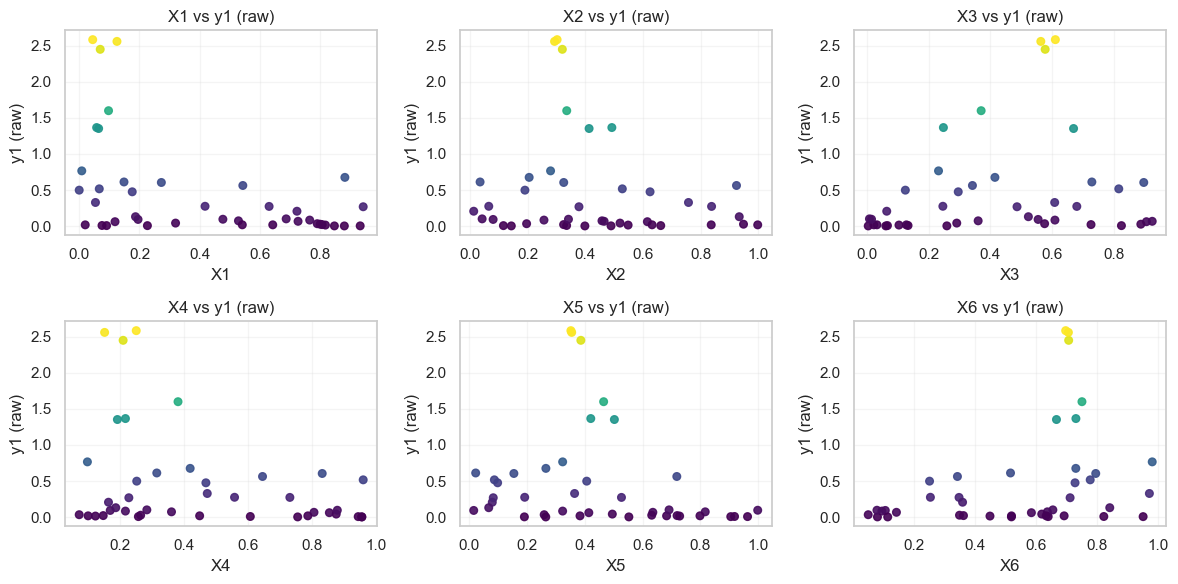

In [17]:
print("\nFeature vs y1 for f7")

# extract inputs and output for f7
input_cols_f7 = [c for c in df_f7.columns if c.startswith("X")]
X_f7 = df_f7[input_cols_f7].values
y_f7 = df_f7["y1"].values

# number of input features (df_f7 has 6)
n_features = X_f7.shape[1]
ncols = 3
nrows = int(np.ceil(n_features / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(4 * ncols, 3 * nrows))

# flatten axes safely
if nrows * ncols == 1:
    axes = [axes]
else:
    axes = axes.ravel().tolist()

# plot each feature
for j, col in enumerate(input_cols_f7):
    ax = axes[j]
    sc = ax.scatter(
        X_f7[:, j],
        y_f7,
        c=y_f7,
        cmap="viridis",
        s=30,
        alpha=0.9
    )
    ax.set_xlabel(col)
    ax.set_ylabel("y1 (raw)")
    ax.set_title(f"{col} vs y1 (raw)")
    ax.grid(alpha=0.2)

# hide unused axes
for k in range(n_features, len(axes)):
    axes[k].axis("off")

plt.tight_layout()
plt.show()


## Distribution Analysis

f7 – feature and output distributions


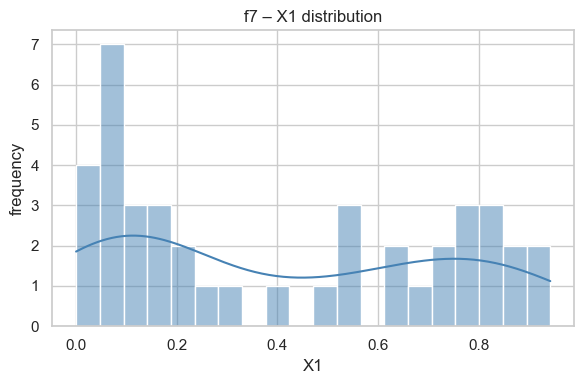

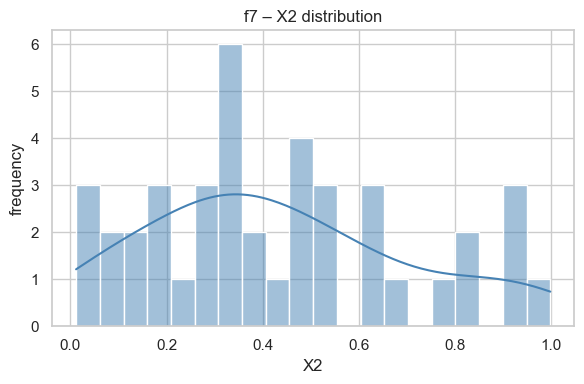

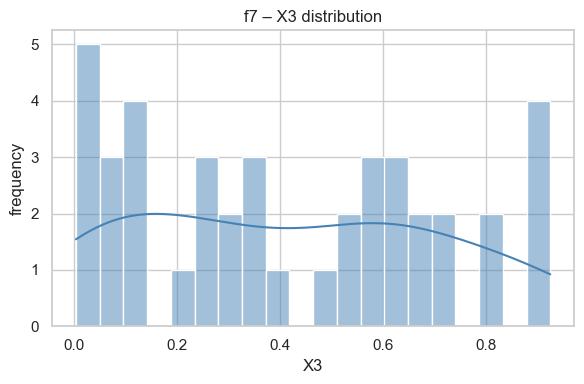

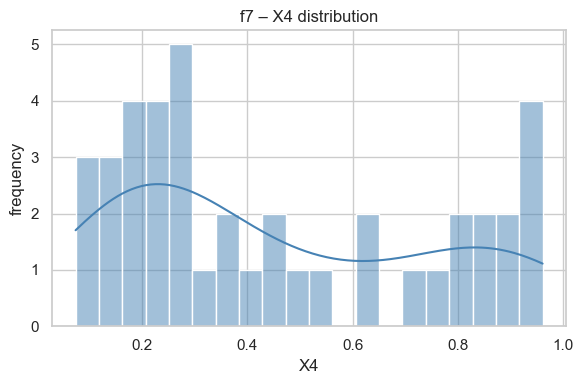

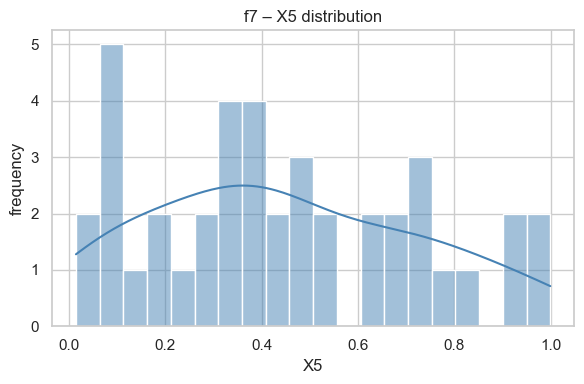

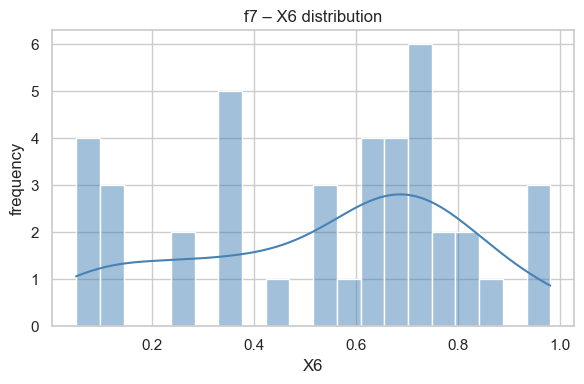

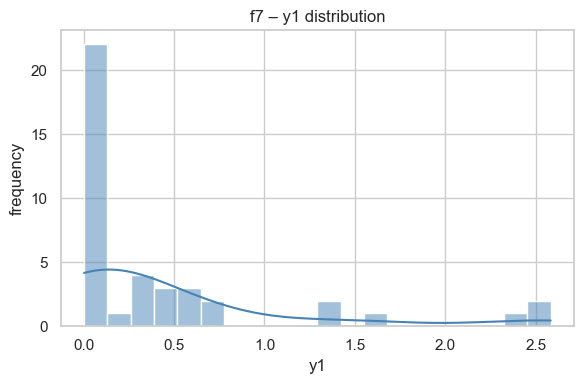

In [18]:
input_cols_f7 = [c for c in df_f7.columns if c.startswith("X")]
output_col_f7 = [c for c in df_f7.columns if c.startswith("y")][0]

print("f7 – feature and output distributions")

all_cols_raw_f7 = input_cols_f7 + [output_col_f7]

for col in all_cols_raw_f7:
    plt.figure(figsize=(6, 4))

    sns.histplot(
        df_f7[col],
        kde=True,
        bins=20,
        color="steelblue"
    )

    plt.title(f"f7 – {col} distribution")
    plt.xlabel(col)
    plt.ylabel("frequency")

    plt.tight_layout()
    plt.show()



## Y vs Instance Index

f7 – y vs instance index


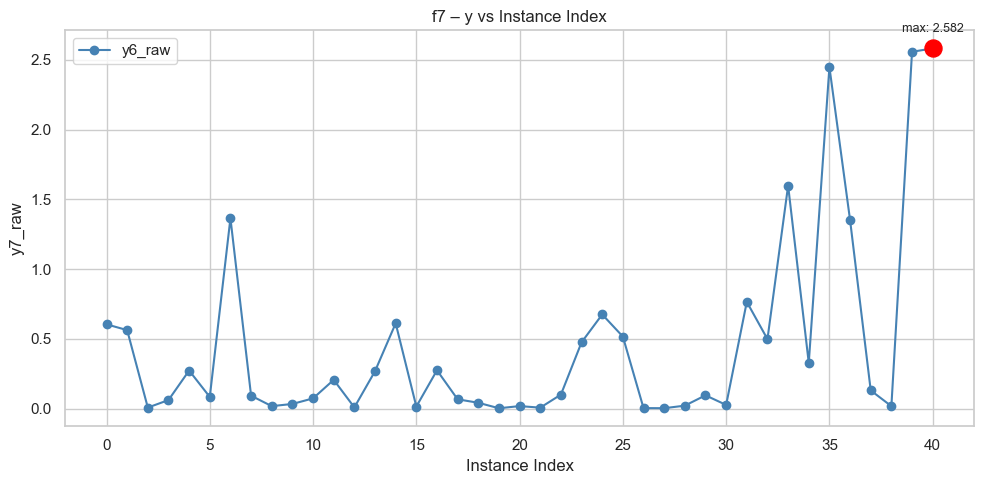

In [19]:
print("f7 – y vs instance index")

# clean copy of raw data
df_f7_plot = df_f7.copy()

# extract raw y
y_raw = df_f7_plot[output_col_f7].values
x = np.arange(len(y_raw))

plt.figure(figsize=(10, 5))

plt.plot(x, y_raw, marker="o", linestyle="-", color="steelblue", label="y6_raw")

# highlight maximum
max_idx = np.argmax(y_raw)
max_val = y_raw[max_idx]

plt.scatter(max_idx, max_val, s=150, color="red", zorder=5)
plt.annotate(
    f"max: {max_val:.3f}",
    (max_idx, max_val),
    textcoords="offset points",
    xytext=(0, 12),
    ha="center",
    fontsize=9
)

plt.title("f7 – y vs Instance Index")
plt.xlabel("Instance Index")
plt.ylabel("y7_raw")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()



## Pearson Correlation

f7 Pearson Correlation Matrix (raw y1)


,X1,X2,X3,X4,X5,X6,y1
X1,1.000000,-0.063772,-0.136210,0.038811,0.079296,-0.516273,-0.470137
X2,-0.063772,1.000000,0.039367,0.145724,0.202533,0.187266,-0.167069
X3,-0.136210,0.039367,1.000000,0.083823,-0.251494,0.116523,0.202627
X4,0.038811,0.145724,0.083823,1.000000,0.106018,-0.078595,-0.306162
X5,0.079296,0.202533,-0.251494,0.106018,1.000000,-0.010234,-0.203720
X6,-0.516273,0.187266,0.116523,-0.078595,-0.010234,1.000000,0.334859
y1,-0.470137,-0.167069,0.202627,-0.306162,-0.203720,0.334859,1.000000


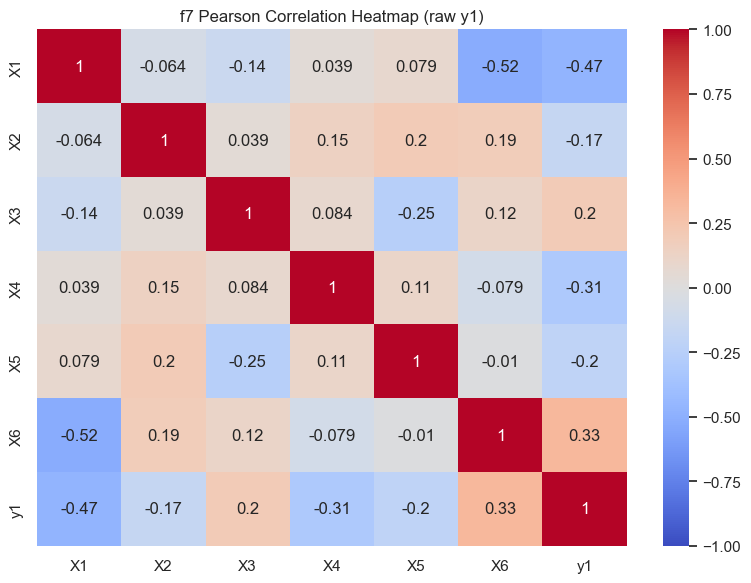

In [20]:
df_raw = df_f7.copy()

print("f7 Pearson Correlation Matrix (raw y1)")

corr_raw = df_raw.corr()
display(corr_raw)

plt.figure(figsize=(8, 6))
sns.heatmap(
    corr_raw,
    annot=True,
    cmap="coolwarm",
    vmin=-1,
    vmax=1
)
plt.title("f7 Pearson Correlation Heatmap (raw y1)")
plt.tight_layout()
plt.show()

## Spearman Correlation

f7 Spearman Correlation Matrix (raw y1)


,X1,X2,X3,X4,X5,X6,y1
X1,1.000000,-0.074913,-0.114634,0.043902,0.032056,-0.472300,-0.485889
X2,-0.074913,1.000000,0.029443,0.208188,0.264634,0.160801,-0.199652
X3,-0.114634,0.029443,1.000000,0.061324,-0.223693,0.162021,0.313415
X4,0.043902,0.208188,0.061324,1.000000,0.114460,-0.034843,-0.260976
X5,0.032056,0.264634,-0.223693,0.114460,1.000000,-0.069338,-0.372125
X6,-0.472300,0.160801,0.162021,-0.034843,-0.069338,1.000000,0.369164
y1,-0.485889,-0.199652,0.313415,-0.260976,-0.372125,0.369164,1.000000


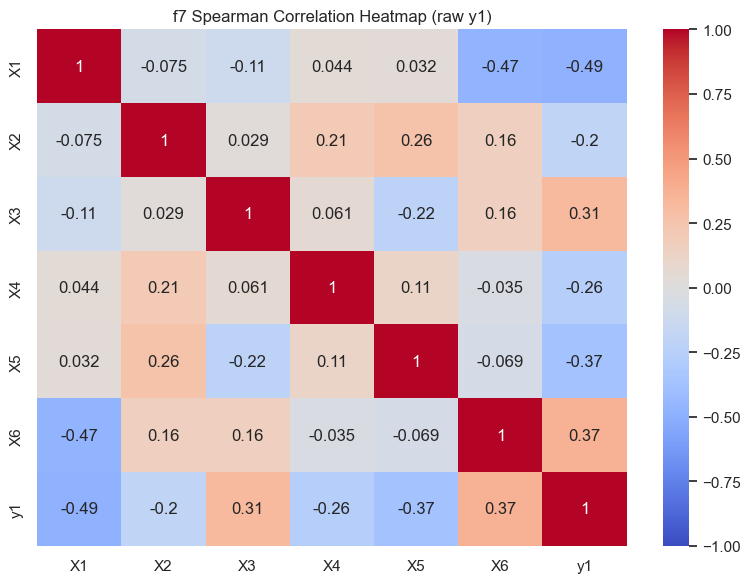

In [21]:
# spearman correlation with raw y1
df_raw = df_f7.copy()

print("f7 Spearman Correlation Matrix (raw y1)")

corr_raw_spearman = df_raw.corr(method="spearman")
display(corr_raw_spearman)

plt.figure(figsize=(8, 6))
sns.heatmap(
    corr_raw_spearman,
    annot=True,
    cmap="coolwarm",
    vmin=-1,
    vmax=1
)
plt.title("f7 Spearman Correlation Heatmap (raw y1)")
plt.tight_layout()
plt.show()


## Kendall Correlation

f7 Kendall Correlation Matrix (raw y1)


,X1,X2,X3,X4,X5,X6,y1
X1,1.000000,-0.034146,-0.073171,0.021951,0.012195,-0.317073,-0.373171
X2,-0.034146,1.000000,0.024390,0.134146,0.187805,0.087805,-0.143902
X3,-0.073171,0.024390,1.000000,0.017073,-0.143902,0.112195,0.207317
X4,0.021951,0.134146,0.017073,1.000000,0.082927,-0.036585,-0.190244
X5,0.012195,0.187805,-0.143902,0.082927,1.000000,-0.046341,-0.239024
X6,-0.317073,0.087805,0.112195,-0.036585,-0.046341,1.000000,0.226829
y1,-0.373171,-0.143902,0.207317,-0.190244,-0.239024,0.226829,1.000000


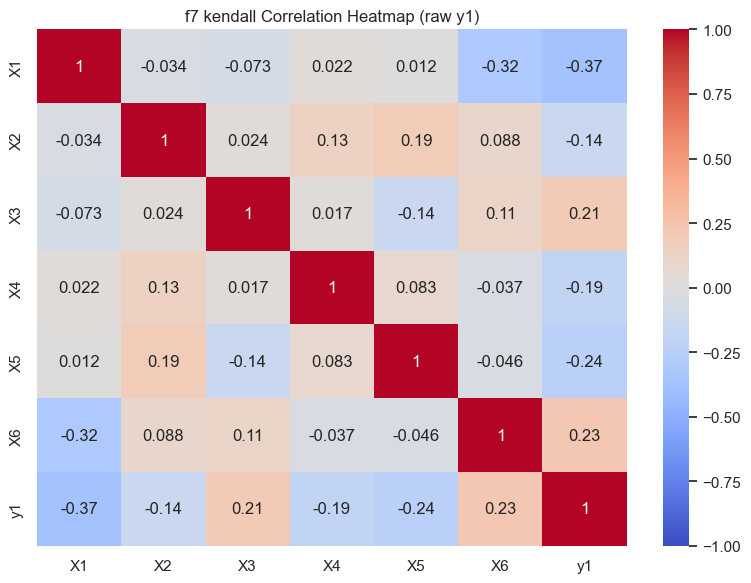

In [22]:
# Kendall correlation with raw y1
df_raw = df_f7.copy()

print("f7 Kendall Correlation Matrix (raw y1)")

corr_raw_kendall = df_raw.corr(method="kendall")
display(corr_raw_kendall)

plt.figure(figsize=(8, 6))
sns.heatmap(
    corr_raw_kendall,
    annot=True,
    cmap="coolwarm",
    vmin=-1,
    vmax=1
)
plt.title("f7 kendall Correlation Heatmap (raw y1)")
plt.tight_layout()
plt.show()


## Mutual Information

In [23]:
from sklearn.feature_selection import mutual_info_regression

print("f7 — Mutual Information with Output")

df_f7_raw = df_f7.copy()

# define inputs and output
input_cols_f7 = [c for c in df_f7_raw.columns if c.startswith("X")]
output_col_f7 = "y1"

X_f7 = df_f7_raw[input_cols_f7].values
y_f7 = df_f7_raw[output_col_f7].values

# compute mutual information
mi_f7 = mutual_info_regression(X_f7, y_f7, random_state=42)

# build dataframe
mi_f7_df = pd.DataFrame({
    "Feature": input_cols_f7,
    "Mutual_Info": mi_f7
}).sort_values(by="Mutual_Info", ascending=False)

display(mi_f7_df)


f7 — Mutual Information with Output


,Feature,Mutual_Info
5,X6,0.259816
0,X1,0.150320
4,X5,0.123054
3,X4,0.050569
1,X2,0.015732
2,X3,0.013591


## Partial Correlation

In [24]:
!pip install pingouin
import pingouin as pg

print("f7 (Raw y1) — Partial Correlation")

df_f7_raw = df_f7.copy()

# define inputs and output
input_cols_f7 = [c for c in df_f7_raw.columns if c.startswith("X")]
output_col_f7 = "y1"

# compute partial correlations for each X feature
for x in input_cols_f7:
    covars = [c for c in input_cols_f7 if c != x]  # all other X's as covariates
    
    pcorr_raw_f7 = pg.partial_corr(
        data=df_f7_raw,
        x=x,
        y=output_col_f7,
        covar=covars
    )
    
    print(f"\nPartial correlation for {x}:")
    display(pcorr_raw_f7)


f7 (Raw y1) — Partial Correlation

Partial correlation for X1:


,n,r,CI95%,p-val
pearson,41,-0.374699,"[-0.63, -0.05]",0.024348



Partial correlation for X2:


,n,r,CI95%,p-val
pearson,41,-0.198527,"[-0.49, 0.14]",0.245754



Partial correlation for X3:


...

,n,r,CI95%,p-val
pearson,41,-0.305749,"[-0.58, 0.03]",0.069762



Partial correlation for X5:


,n,r,CI95%,p-val
pearson,41,-0.087424,"[-0.4, 0.25]",0.612151



Partial correlation for X6:


,n,r,CI95%,p-val
pearson,41,0.140605,"[-0.2, 0.45]",0.413397


## Sliced Inverse Regression


SIR for f7

leading SIR direction (most important 1D projection):
  X1: -0.5918
  X2: -0.0883
  X3: 0.2237
  X4: -0.3617
  X5: -0.4498
  X6: 0.5087

second SIR direction (additional structure):
  X1: -0.1577
  X2: 0.3713
  X3: -0.7283
  X4: -0.0400
  X5: 0.3166
  X6: 0.4528

leading eigenvalues:
  λ1 = 0.7643
  λ2 = 0.4893  (ratio λ2/λ1 = 0.640)

bootstrap stability of leading direction:
  mean angle: 50.48 deg
  std angle:  36.74 deg
  class:      moderately stable
  n_boot:     150


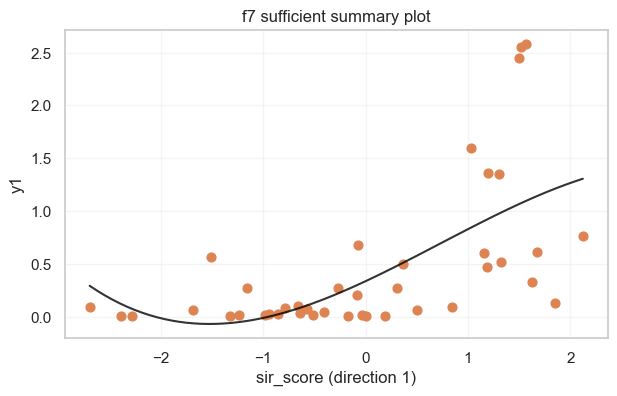

{'sir_dir1': array([-0.59176377, -0.08833265,  0.22371886, -0.36172464, -0.44982385,
         0.50870093]),
 'sir_dir2': array([-0.15765822,  0.37133663, -0.72826724, -0.04000196,  0.3165659 ,
         0.45284179]),
 'eigvals': array([0.76433604, 0.48928269, 0.23758752, 0.18004916, 0.07662067,
        0.05111431]),
 'scores': array([ 1.15920572, -1.50863695, -0.16977776,  0.49831604, -1.16169026,
        -0.78901717,  1.19295168,  0.84535068, -0.5146849 , -0.64424543,
        -0.56668509, -0.08397115,  0.00780628,  0.30627855,  1.66920317,
        -1.23942655, -0.27346241, -1.68695443, -0.40119385, -2.28142965,
        -0.98312411,  0.18850403, -0.65458518,  1.18456178, -0.07779639,
         1.32407072, -1.31897692, -2.38176508, -0.85048564, -2.69233963,
        -0.94408502,  2.12063933,  0.37037059,  1.02990423,  1.62509956,
         1.4999576 ,  1.30606213,  1.84893432, -0.03489322,  1.51787165,
         1.56413876])}

In [25]:
from sklearn.preprocessing import StandardScaler
from sklearn.utils import resample


# Sliced Inverse Regression (SIR)
# SIR is a dimension-reduction method for regression.
# Instead of modelling y | x, it studies the inverse structure x | y.
# The idea:
#   1. Standardise X.
#   2. Slice y into quantile bins.
#   3. Compute the mean of X in each slice.
#   4. The covariance of these slice means reveals directions in X
#      that are most associated with changes in y.
#   5. Eigenvectors of this covariance give the "effective dimension"
#      directions (EDRs).
#   6. The first direction is the strongest 1D summary of X for predicting y.
#   7. The second direction often carries additional structure.
def sliced_inverse_regression(X, y, n_slices=8):
    # standardise X so all features have mean 0 and variance 1
    scaler = StandardScaler()
    Xs = scaler.fit_transform(X)

    n, p = Xs.shape

    # ensure number of slices is valid
    n_slices = min(max(2, int(n_slices)), max(2, n))

    # slice y into quantile bins
    quantiles = np.linspace(0.0, 1.0, n_slices + 1)
    bins = np.quantile(y, quantiles)
    bins[0] -= 1e-12
    bins[-1] += 1e-12
    slice_idx = np.digitize(y, bins) - 1

    # compute slice means of X and slice probabilities
    slice_means = np.zeros((n_slices, p))
    slice_probs = np.zeros(n_slices)
    for s in range(n_slices):
        mask = slice_idx == s
        if mask.sum() > 0:
            slice_means[s] = Xs[mask].mean(axis=0)
            slice_probs[s] = mask.sum() / n

    # between-slice covariance matrix
    # this captures how X changes as y moves across slices
    cov = np.zeros((p, p))
    for s in range(n_slices):
        m = slice_means[s].reshape(-1, 1)
        cov += slice_probs[s] * (m @ m.T)

    # eigen-decomposition of the covariance
    # eigenvectors = SIR directions
    eigvals, eigvecs = np.linalg.eigh(cov)
    idx = np.argsort(eigvals)[::-1]

    # normalise directions
    dirs = eigvecs[:, idx]
    dirs = dirs / (np.linalg.norm(dirs, axis=0) + 1e-12)

    # SIR scores = projection of X onto the first direction
    sir_scores = Xs @ dirs[:, 0]

    return dirs, sir_scores, scaler, eigvals[idx]



# Bootstrap stability of the leading SIR direction
# SIR can be unstable at small sample sizes.
# Bootstrap resampling gives a distribution of angles between
# the original SIR direction and bootstrap SIR directions.
# A small angle means stable; a large angle means unstable.
def sir_bootstrap_stability(X, y, n_slices=8, n_boot=100, random_state=0):
    rng = np.random.RandomState(random_state)

    # compute base SIR direction
    base_dirs, _, _, _ = sliced_inverse_regression(X, y, n_slices=n_slices)
    base = base_dirs[:, 0]

    angles = []

    for _ in range(n_boot):
        Xb, yb = resample(X, y, replace=True, random_state=rng)
        try:
            dirs_b, _, _, _ = sliced_inverse_regression(Xb, yb, n_slices=n_slices)
            db = dirs_b[:, 0]

            # angle between base direction and bootstrap direction
            cosang = np.clip(
                np.dot(base, db) /
                (np.linalg.norm(base) * np.linalg.norm(db) + 1e-12),
                -1.0, 1.0
            )
            angles.append(np.arccos(cosang))
        except Exception:
            continue

    angles = np.array(angles)
    mean_deg = np.degrees(np.nanmean(angles))
    std_deg = np.degrees(np.nanstd(angles))

    # stability classification
    if mean_deg < 30:
        cls = "stable"
    elif mean_deg < 60:
        cls = "moderately stable"
    else:
        cls = "unstable"

    return {
        "mean_angle_deg": mean_deg,
        "std_angle_deg": std_deg,
        "class": cls,
        "n_boot": len(angles)
    }



# Main SIR analysis for df_f7
# Includes:
#   - leading and second SIR directions
#   - bootstrap stability classification
#   - polynomial smoothing on the sufficient summary plot

def run_sir_f7(df_f7, n_slices=8, bootstrap_checks=True):
    input_cols = [c for c in df_f7.columns if c.startswith("X")]
    output_col = "y1"

    X = df_f7[input_cols].values.astype(float)
    y = df_f7[output_col].values.astype(float)

    # compute SIR directions
    dirs, sir_scores, scaler, eigvals = sliced_inverse_regression(X, y, n_slices=n_slices)
    sir_dir1 = dirs[:, 0]
    sir_dir2 = dirs[:, 1]

    print("\nSIR for f7")

    # print leading direction
    print("\nleading SIR direction (most important 1D projection):")
    for col, v in zip(input_cols, sir_dir1):
        print(f"  {col}: {v:.4f}")

    # print second direction
    print("\nsecond SIR direction (additional structure):")
    for col, v in zip(input_cols, sir_dir2):
        print(f"  {col}: {v:.4f}")

    # eigenvalues show how much variance each direction explains
    print("\nleading eigenvalues:")
    print(f"  λ1 = {eigvals[0]:.4f}")
    print(f"  λ2 = {eigvals[1]:.4f}  (ratio λ2/λ1 = {eigvals[1]/eigvals[0]:.3f})")

    # bootstrap stability
    if bootstrap_checks:
        stab = sir_bootstrap_stability(X, y, n_slices=n_slices, n_boot=150)
        print("\nbootstrap stability of leading direction:")
        print(f"  mean angle: {stab['mean_angle_deg']:.2f} deg")
        print(f"  std angle:  {stab['std_angle_deg']:.2f} deg")
        print(f"  class:      {stab['class']}")
        print(f"  n_boot:     {stab['n_boot']}")

    # sufficient summary plot
    plt.figure(figsize=(7,4))
    plt.scatter(sir_scores, y, c="C1", s=40)
    plt.xlabel("sir_score (direction 1)")
    plt.ylabel("y1")
    plt.title("f7 sufficient summary plot")
    plt.grid(alpha=0.2)

    # polynomial smoothing (degree 3)
    try:
        coeffs = np.polyfit(sir_scores, y, 3)
        xs = np.linspace(sir_scores.min(), sir_scores.max(), 200)
        ys = np.polyval(coeffs, xs)
        plt.plot(xs, ys, color="black", linewidth=1.5, alpha=0.8)
    except Exception:
        pass

    plt.show()

    return {
        "sir_dir1": sir_dir1,
        "sir_dir2": sir_dir2,
        "eigvals": eigvals,
        "scores": sir_scores
    }


run_sir_f7(df_f7, n_slices=8, bootstrap_checks=True)

## 2D Geodesic Embedding

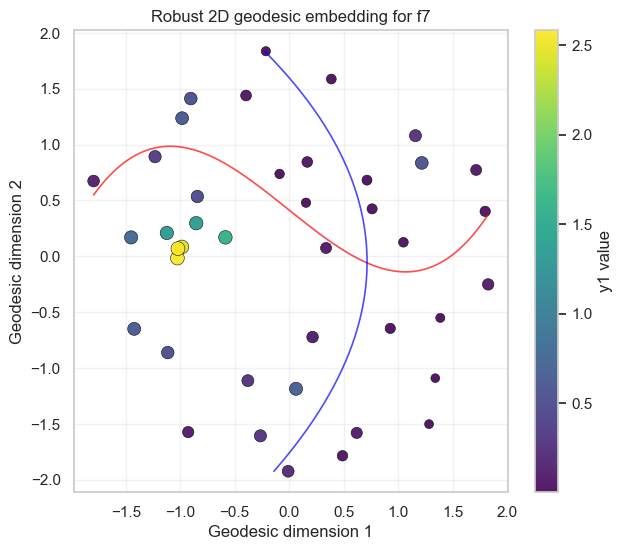

{'embedding': array([[-0.98254793,  1.23602997],
        [ 1.21652338,  0.83584174],
        [ 0.15425435,  0.47957942],
        [-0.39563557,  1.43904871],
        [ 1.15860702,  1.07969383],
        [ 0.61981899, -1.58087707],
        [-0.85288115,  0.29625133],
        [-0.92649748, -1.57349524],
        [ 0.71371786,  0.68159267],
        [ 0.48926831, -1.78547913],
        [ 0.33818432,  0.07421289],
        [-0.0093097 , -1.92412781],
        [-0.08797171,  0.73704279],
        [-0.37906955, -1.11318141],
        [-1.42202731, -0.64974483],
        [ 1.04810466,  0.12546344],
        [-0.26373378, -1.60694023],
        [ 1.71556025,  0.77278143],
        [ 0.16582735,  0.84441134],
        [ 1.34052684, -1.09094246],
        [ 0.7610032 ,  0.42465908],
        [-0.21404043,  1.83529848],
        [ 0.21458434, -0.72294358],
        [-0.84253929,  0.5349456 ],
        [ 0.06282901, -1.18591939],
        [-0.90282867,  1.41171711],
        [ 1.38637403, -0.55145518],
        [ 1.283

In [26]:
from sklearn.metrics import pairwise_distances
from sklearn.manifold import MDS


def robust_isomap_2d(X, k=6, eps_factor=0.25):
    """
    Robust Isomap-like embedding that never fails.
    Builds a hybrid graph:
      - k-NN edges
      - epsilon-radius edges (eps = eps_factor * median distance)
    Ensures graph connectivity and computes geodesic distances.
    Uses classical MDS to obtain a 2D embedding.
    """

    # standardise X
    scaler = StandardScaler()
    Xs = scaler.fit_transform(X)

    # pairwise distances
    D = pairwise_distances(Xs)

    # k-NN graph
    n = len(X)
    knn_graph = np.full((n, n), np.inf)
    for i in range(n):
        idx = np.argsort(D[i])[1:k+1]
        knn_graph[i, idx] = D[i, idx]
        knn_graph[idx, i] = D[idx, i]

    # epsilon graph to guarantee connectivity
    eps = eps_factor * np.median(D)
    eps_graph = np.where(D <= eps, D, np.inf)

    # hybrid graph
    G = np.minimum(knn_graph, eps_graph)

    # Floyd–Warshall for geodesic distances
    geo = G.copy()
    for k in range(n):
        geo = np.minimum(geo, geo[:, k][:, None] + geo[k, :][None, :])

    # classical MDS on geodesic distances
    mds = MDS(n_components=2, dissimilarity="precomputed", random_state=0)
    emb = mds.fit_transform(geo)

    # standardise embedding
    emb = (emb - emb.mean(axis=0)) / (emb.std(axis=0) + 1e-12)

    return emb, scaler, geo


def run_isomap_f7(df_f7):
    input_cols = [c for c in df_f7.columns if c.startswith("X")]
    X = df_f7[input_cols].values.astype(float)
    y = df_f7["y1"].values.astype(float)

    ranks = np.argsort(np.argsort(y))
    sizes = 40 + 60 * (ranks / ranks.max())

    # robust embedding
    emb, scaler, geo = robust_isomap_2d(X, k=6, eps_factor=0.25)

    # plot
    plt.figure(figsize=(7, 6))
    sc = plt.scatter(
        emb[:, 0], emb[:, 1],
        c=y, s=sizes,
        cmap="viridis",
        alpha=0.9,
        edgecolor="black",
        linewidth=0.4
    )
    plt.xlabel("Geodesic dimension 1")
    plt.ylabel("Geodesic dimension 2")
    plt.title("Robust 2D geodesic embedding for f7")
    plt.grid(alpha=0.25)
    plt.colorbar(sc, label="y1 value")

    # polynomial smoothing along each axis
    try:
        coeffs_x = np.polyfit(emb[:, 0], y, 3)
        xs = np.linspace(emb[:, 0].min(), emb[:, 0].max(), 200)
        ys = np.polyval(coeffs_x, xs)
        plt.plot(xs, ys, color="red", linewidth=1.2, alpha=0.7)
    except Exception:
        pass

    try:
        coeffs_y = np.polyfit(emb[:, 1], y, 3)
        ys2 = np.linspace(emb[:, 1].min(), emb[:, 1].max(), 200)
        xs2 = np.polyval(coeffs_y, ys2)
        plt.plot(xs2, ys2, color="blue", linewidth=1.2, alpha=0.7)
    except Exception:
        pass

    plt.show()

    return {"embedding": emb, "geodesic_distances": geo, "scaler": scaler}


run_isomap_f7(df_f7)

## K means Clustering


K-means clustering for df_f7 (focused high-value analysis)

high-value cluster: 1
mean y1 in this cluster: 1.226009

members of high-value cluster (row indices):
[6, 14, 23, 31, 32, 33, 34, 35, 36, 37, 39, 40]

centroid of high-value cluster (6D):
         X1       X2        X3        X4        X5        X6
0  0.086134  0.41435  0.462432  0.267448  0.313303  0.712594

within-cluster variance per dimension:
  dimension  within_cluster_variance
0        X1                 0.003460
1        X2                 0.057894
2        X3                 0.036215
3        X4                 0.013192
4        X5                 0.023507
5        X6                 0.034216


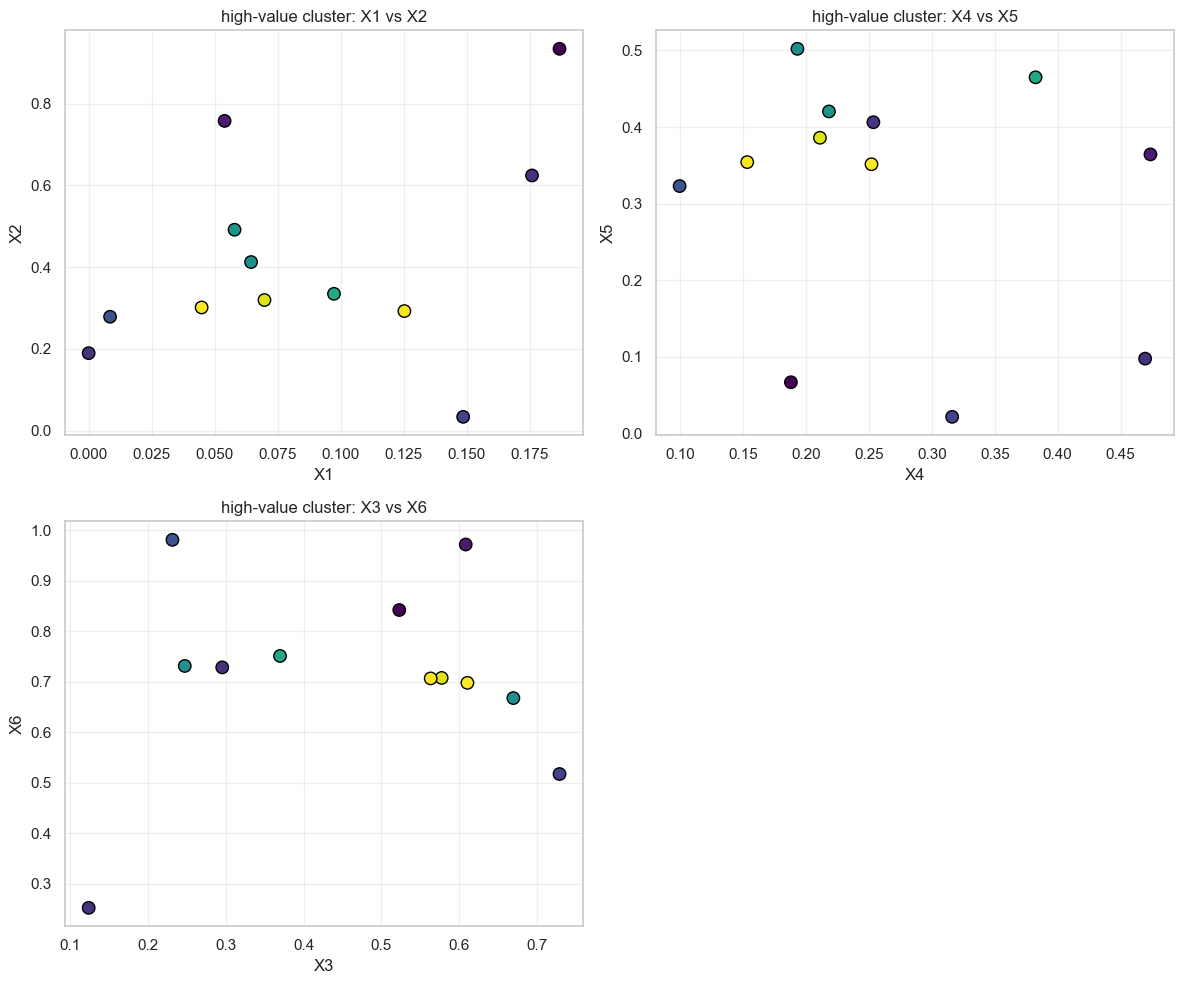

In [27]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# focused k-means clustering for df_f7 with emphasis on the high-value cluster

print("\nK-means clustering for df_f7 (focused high-value analysis)")

# extract input and output columns
input_cols = [col for col in df_f7.columns if col.startswith("X")]
output_col = "y1"

# convert to arrays
X_f7 = df_f7[input_cols].values.astype(float)
y_f7 = df_f7[output_col].values.astype(float)

# run k-means with k=6 (confirmed optimal)
k = 6
kmeans = KMeans(n_clusters=k, random_state=42)
kmeans.fit(X_f7)

# assign cluster labels
labels = kmeans.labels_
df_f7["cluster"] = labels

# compute mean y1 for each cluster
cluster_means = df_f7.groupby("cluster")[output_col].mean()

# identify the cluster with the highest mean y1
high_cluster = cluster_means.idxmax()
print(f"\nhigh-value cluster: {high_cluster}")
print(f"mean y1 in this cluster: {cluster_means[high_cluster]:.6f}")

# list the row indices belonging to the high-value cluster
members = df_f7.index[df_f7["cluster"] == high_cluster].tolist()
print("\nmembers of high-value cluster (row indices):")
print(members)

# extract the centroid of the high-value cluster
centroid = kmeans.cluster_centers_[high_cluster]
centroid_df = pd.DataFrame([centroid], columns=input_cols)
print("\ncentroid of high-value cluster (6D):")
print(centroid_df)

# compute within-cluster variance for each dimension
X_cluster = X_f7[df_f7["cluster"] == high_cluster]
var_within = X_cluster.var(axis=0)

var_df = pd.DataFrame({
    "dimension": input_cols,
    "within_cluster_variance": var_within
})
print("\nwithin-cluster variance per dimension:")
print(var_df)

# scatter plots showing only the high-value cluster members
plt.figure(figsize=(12, 10))

# choose three informative feature pairs
pairs = [(0, 1), (3, 4), (2, 5)]  # X1 vs X2, X4 vs X5, X3 vs X6

for i, (a, b) in enumerate(pairs, 1):
    plt.subplot(2, 2, i)
    plt.scatter(
        X_cluster[:, a],
        X_cluster[:, b],
        c=y_f7[df_f7["cluster"] == high_cluster],
        cmap="viridis",
        s=80,
        edgecolor="black"
    )
    plt.xlabel(input_cols[a])
    plt.ylabel(input_cols[b])
    plt.title(f"high-value cluster: {input_cols[a]} vs {input_cols[b]}")
    plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()



## Active Subspace Detection via Gradient-Based Dimension Reduction

**Reference:** Constantine, P.G., Dow, E. and Wang, Q. (2014) 'Active subspace methods in theory and practice: applications to kriging surfaces', SIAM Journal on Scientific Computing, 36(4), pp. A1500–A1524. Available at: https://doi.org/10.1137/130916138

- Used for f7 because the function has 6 input dimensions but the EDA consistently shows only 3 dimensions (X1, X5, X6) carrying meaningful signal, and active subspace detection quantifies how many effective dimensions the function has near the current best by decomposing the average squared gradient matrix, directly informing whether the trust region should be a hyper-rectangle or an oriented ellipsoid aligned with the true directions of variation.


active subspace detection
eigenvalues (top 4): [5.2955 1.4456 0.6373 0.1131]
consecutive eigenvalue ratios: [0.273  0.4409 0.1775]
effective dimensionality estimate:
  function appears effectively 3d (ratio 0.178 < 0.20)

leading active subspace direction (w1):
  X1: -0.0828
  X2: -0.5555
  X3: 0.0049
  X4: -0.1211
  X5: -0.7836
  X6: -0.2363

second active subspace direction (w2):
  X1: -0.0764
  X2: -0.0073
  X3: 0.0019
  X4: -0.0015
  X5: 0.3002
  X6: -0.9508


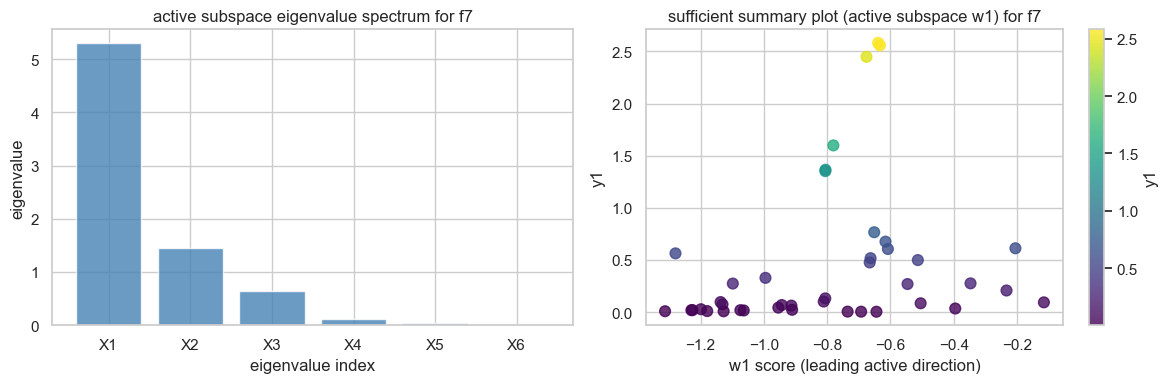

In [28]:
from sklearn.gaussian_process import GaussianProcessRegressor as GPR
from sklearn.gaussian_process.kernels import Matern, WhiteKernel, ConstantKernel as C
from sklearn.linear_model import LinearRegression

# method: active subspace detection via finite differences
# source: high-dimensional bo survey (neurips 2024) and dimension_reduction.pdf
# estimates the matrix of average squared directional derivatives
# using finite differences on existing observations
# eigenvalues rank how much variance each direction explains
# eigenvectors define the active subspace directions

def compute_active_subspace(df, feature_cols, target_col, delta=0.05):
    """
    estimates the active subspace of the function using finite differences.
    the active subspace is the low-dimensional subspace where the function
    varies most, identified by the dominant eigenvectors of the matrix
    c = e[grad f * grad f^t], approximated from finite differences.

    parameters
    ----------
    df : dataframe containing features and target
    feature_cols : list of input column names
    target_col : output column name
    delta : finite difference step size (default 0.05)
    """

    X = df[feature_cols].values
    y = df[target_col].values
    n, d = X.shape

    # fit a gp to approximate the function for finite difference computation
    # matern 2.5 with ard is used to respect per-dimension length scales
    kernel = C(1.0, (1e-2, 1e2)) * Matern(
        length_scale=np.ones(d),
        length_scale_bounds=[(0.05, 5.0)] * d,
        nu=2.5
    ) + WhiteKernel(noise_level=1e-4, noise_level_bounds=(1e-6, 0.1))

    gp = GPR(kernel=kernel, normalize_y=True, n_restarts_optimizer=5)
    gp.fit(X, y)

    # compute finite difference gradient at each observed point
    # grad_f[i, j] = (f(x + delta*e_j) - f(x - delta*e_j)) / (2*delta)
    # this is the central difference approximation of the partial derivative
    grad_matrix = np.zeros((n, d))

    for i in range(n):
        for j in range(d):
            x_plus = X[i].copy()
            x_minus = X[i].copy()
            x_plus[j] = np.clip(X[i, j] + delta, 0.0, 1.0)
            x_minus[j] = np.clip(X[i, j] - delta, 0.0, 1.0)

            f_plus = gp.predict(x_plus.reshape(1, -1))[0]
            f_minus = gp.predict(x_minus.reshape(1, -1))[0]

            # use actual delta after clipping
            actual_delta = x_plus[j] - x_minus[j]
            if actual_delta > 1e-8:
                grad_matrix[i, j] = (f_plus - f_minus) / actual_delta
            else:
                grad_matrix[i, j] = 0.0

    # active subspace matrix c = (1/n) * sum_i grad_i * grad_i^t
    # shape (d, d), symmetric positive semidefinite
    C_matrix = (grad_matrix.T @ grad_matrix) / n

    # eigendecomposition: eigenvalues in descending order
    eigenvalues, eigenvectors = np.linalg.eigh(C_matrix)
    sort_idx = np.argsort(eigenvalues)[::-1]
    eigenvalues = eigenvalues[sort_idx]
    eigenvectors = eigenvectors[:, sort_idx]

    # eigenvalue ratio: consecutive ratio < 0.1 indicates effective dimensionality
    # e.g. if eigenvalue[1] / eigenvalue[0] < 0.1, function is effectively 1d
    ratios = eigenvalues[1:] / (eigenvalues[:-1] + 1e-12)

    print("\nactive subspace detection")
    print(f"eigenvalues (top {min(d, 4)}): {eigenvalues[:4].round(4)}")
    print(f"consecutive eigenvalue ratios: {ratios[:3].round(4)}")
    print("effective dimensionality estimate:")
    for k in range(1, d):
        if ratios[k-1] < 0.20:
            print(f"  function appears effectively {k}d (ratio {ratios[k-1]:.3f} < 0.20)")
            break
    else:
        print(f"  function appears effectively {d}d (no clear eigenvalue gap)")

    print("\nleading active subspace direction (w1):")
    for i, col in enumerate(feature_cols):
        print(f"  {col}: {eigenvectors[i, 0]:.4f}")

    print("\nsecond active subspace direction (w2):")
    for i, col in enumerate(feature_cols):
        print(f"  {col}: {eigenvectors[i, 1]:.4f}")

    # plot eigenvalue spectrum
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    axes[0].bar(range(1, d+1), eigenvalues, color="steelblue", alpha=0.8)
    axes[0].set_xlabel("eigenvalue index")
    axes[0].set_ylabel("eigenvalue")
    axes[0].set_title("active subspace eigenvalue spectrum for f7")
    axes[0].set_xticks(range(1, d+1))
    axes[0].set_xticklabels(feature_cols)

    # sufficient summary plot along leading active subspace direction
    active_scores = X @ eigenvectors[:, 0]
    axes[1].scatter(active_scores, y, c=y, cmap="viridis", s=60, alpha=0.8)
    axes[1].set_xlabel("w1 score (leading active direction)")
    axes[1].set_ylabel("y1")
    axes[1].set_title("sufficient summary plot (active subspace w1) for f7")
    plt.colorbar(axes[1].collections[0], ax=axes[1], label="y1")

    plt.tight_layout()
    plt.show()

    return eigenvalues, eigenvectors, grad_matrix


eigenvalues_f7, eigenvectors_f7, grad_f7 = compute_active_subspace(
    df_f7,
    feature_cols=["X1", "X2", "X3", "X4", "X5", "X6"],
    target_col="y1"
)

## Local Linear Embedding of the High-Value Neighbourhood


**Reference:** Roweis, S.T. and Saul, L.K. (2000) 'Nonlinear dimensionality reduction by locally linear embedding', Science, 290(5500), pp. 2323–2326. Available at: https://doi.org/10.1126/science.290.5500.2323

- Used for f7 because the global SIR direction has bootstrap stability angles between 53 and 79 degrees across weeks, indicating it is only moderately reliable, and a local linear fit restricted to the top-10 observations produces a gradient direction specific to the confirmed high-value neighbourhood rather than the full dataset, making it more trustworthy for acquisition guidance in the exploitation phase.


local linear gradient (top 10 observations)
y range in local neighbourhood: [0.6044, 2.5822]
observations included:
  idx=40: y=2.5822
  idx=39: y=2.5580
  idx=35: y=2.4483
  idx=33: y=1.5985
  idx=6: y=1.3650
  idx=36: y=1.3516
  idx=31: y=0.7654
  idx=24: y=0.6751
  idx=14: y=0.6115
  idx=0: y=0.6044

local linear model r2: 0.5172
local gradient direction (standardised coefficients):
  X1: -0.1058  (normalised: -0.1577)  -> decrease
  X2: -0.1052  (normalised: -0.1568)  -> decrease
  X3: 0.3105  (normalised: 0.4627)  -> increase
  X4: -0.2507  (normalised: -0.3736)  -> decrease
  X5: 0.5131  (normalised: 0.7646)  -> increase
  X6: -0.0744  (normalised: -0.1109)  -> decrease

local gradient vs sir: positive = agree, negative = disagree
  X1: dot product = 0.0927  (agree)
  X2: dot product = 0.0091  (agree)
  X3: dot product = 0.0836  (agree)
  X4: dot product = 0.1307  (agree)
  X5: dot product = -0.3529  (DISAGREE)
  X6: dot product = -0.0590  (DISAGREE)


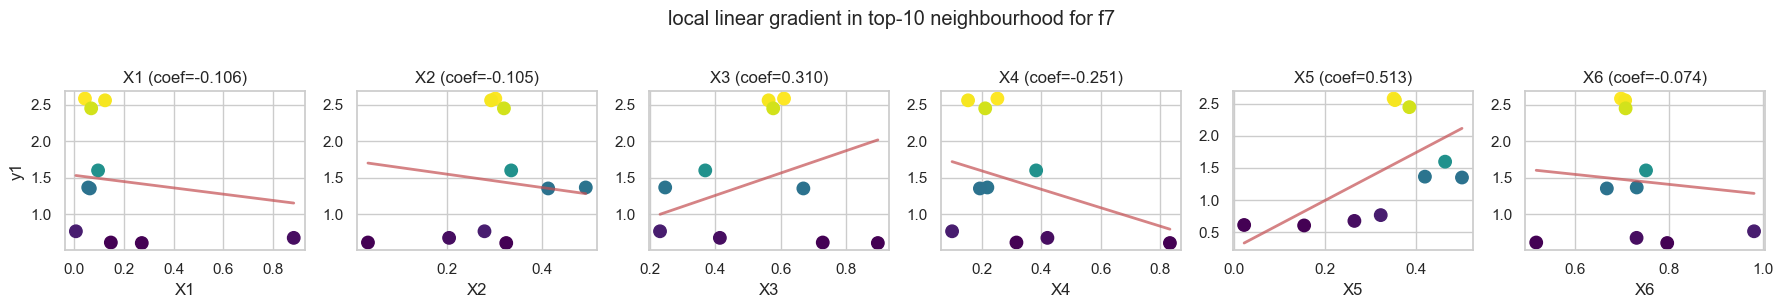

In [29]:
# method: local linear embedding of high-value neighbourhood
# source: dimension_reduction.pdf and latent_space.pdf
# fits a local linear model to the top-n observations only
# the coefficients give the local gradient direction near the peak
# more reliable than sir at small n because it focuses on the
# high-value region rather than the full dataset


def local_linear_gradient(df, feature_cols, target_col, top_n=10):
    """
    fits a local linear model to the top-n observations by y value.
    the regression coefficients approximate the local gradient direction
    in the neighbourhood of the current best observations.
    this direction can replace or augment the sir direction as the
    acquisition boost in the trust region ensemble.

    parameters
    ----------
    df : dataframe containing features and target
    feature_cols : list of input column names
    target_col : output column name
    top_n : number of top observations to include in local fit
    """

    # select top-n observations by y value
    df_sorted = df.nlargest(top_n, target_col)
    X_local = df_sorted[feature_cols].values
    y_local = df_sorted[target_col].values

    print(f"\nlocal linear gradient (top {top_n} observations)")
    print(f"y range in local neighbourhood: [{y_local.min():.4f}, {y_local.max():.4f}]")
    print("observations included:")
    for idx in df_sorted.index:
        row = df_sorted.loc[idx]
        print(f"  idx={idx}: y={row[target_col]:.4f}")

    # standardise inputs for comparable coefficients
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X_local)

    # fit local linear model
    # coefficients give the direction of steepest ascent in the local neighbourhood
    lr = LinearRegression()
    lr.fit(X_scaled, y_local)

    coefs = lr.coef_
    coef_norm = coefs / (np.linalg.norm(coefs) + 1e-12)

    print(f"\nlocal linear model r2: {lr.score(X_scaled, y_local):.4f}")
    print("local gradient direction (standardised coefficients):")
    for i, col in enumerate(feature_cols):
        direction = "increase" if coefs[i] > 0 else "decrease"
        print(f"  {col}: {coefs[i]:.4f}  (normalised: {coef_norm[i]:.4f})  -> {direction}")

    # compare with sir direction if available
    print("\nlocal gradient vs sir: positive = agree, negative = disagree")
    sir_direction = np.array([-0.5876, -0.0582, 0.1807, -0.3498, -0.4615, 0.5324])
    agreement = coef_norm * sir_direction
    for i, col in enumerate(feature_cols):
        symbol = "agree" if agreement[i] > 0 else "DISAGREE"
        print(f"  {col}: dot product = {agreement[i]:.4f}  ({symbol})")

    # plot local linear fit: actual vs predicted in local neighbourhood
    fig, axes = plt.subplots(1, len(feature_cols), figsize=(18, 3))
    for i, col in enumerate(feature_cols):
        axes[i].scatter(X_local[:, i], y_local, c=y_local, cmap="viridis", s=80)
        # overlay linear fit line
        x_range = np.linspace(X_local[:, i].min(), X_local[:, i].max(), 50)
        x_full = np.tile(X_local.mean(axis=0), (50, 1))
        x_full[:, i] = x_range
        x_full_scaled = scaler.transform(x_full)
        y_pred = lr.predict(x_full_scaled)
        axes[i].plot(x_range, y_pred, "r-", linewidth=2, alpha=0.7)
        axes[i].set_xlabel(col)
        axes[i].set_ylabel("y1" if i == 0 else "")
        axes[i].set_title(f"{col} (coef={coefs[i]:.3f})")

    plt.suptitle(f"local linear gradient in top-{top_n} neighbourhood for f7", y=1.02)
    plt.tight_layout()
    plt.show()

    return coefs, coef_norm, lr, scaler


local_coefs_f7, local_coef_norm_f7, local_lr_f7, local_scaler_f7 = local_linear_gradient(
    df_f7,
    feature_cols=["X1", "X2", "X3", "X4", "X5", "X6"],
    target_col="y1",
    top_n=10
)

## GP Posterior Variance Decomposition by Dimension

**Reference:** Rasmussen, C.E. and Williams, C.K.I. (2006) Gaussian Processes for Machine Learning. Cambridge, MA: MIT Press. Available at: http://www.gaussianprocess.org/gpml/

- Used for f7 because the week 9 failure was caused by pure variance maximisation selecting a point at X2=0.998 in a topologically disconnected low-value region, and variance decomposition at the incumbent identifies which dimensions have high posterior uncertainty in directions that also have positive mean gradient, separating informative uncertainty from irrelevant uncertainty in unexplored low-value regions.


gp posterior variance decomposition
fitted kernel: 0.701**2 * Matern(length_scale=[0.729, 0.344, 5, 0.741, 0.247, 0.238], nu=2.5) + WhiteKernel(noise_level=1e-06)

incumbent: idx=40, y=2.5822
posterior std at incumbent: 0.000988

variance sensitivity (change in posterior std per dimension):
high sensitivity = gp is most uncertain in this direction
  X1: delta_sigma=0.029070  mean_grad=-0.4351  sigma+=0.0301  sigma-=0.0286
  X2: delta_sigma=0.065717  mean_grad=-1.9252  sigma+=0.0561  sigma-=0.0667
  X3: delta_sigma=0.005320  mean_grad=0.0166  sigma+=0.0063  sigma-=0.0063
  X4: delta_sigma=0.022825  mean_grad=-0.8357  sigma+=0.0238  sigma-=0.0231
  X5: delta_sigma=0.063745  mean_grad=-1.0639  sigma+=0.0409  sigma-=0.0647
  X6: delta_sigma=0.098644  mean_grad=-0.9045  sigma+=0.0893  sigma-=0.0996

dimensions ranked by variance sensitivity (most to least):
  rank 1: X6 (sensitivity=0.098644, mean_grad=-0.9045)
  rank 2: X2 (sensitivity=0.065717, mean_grad=-1.9252)
  rank 3: X5 (sensitivit

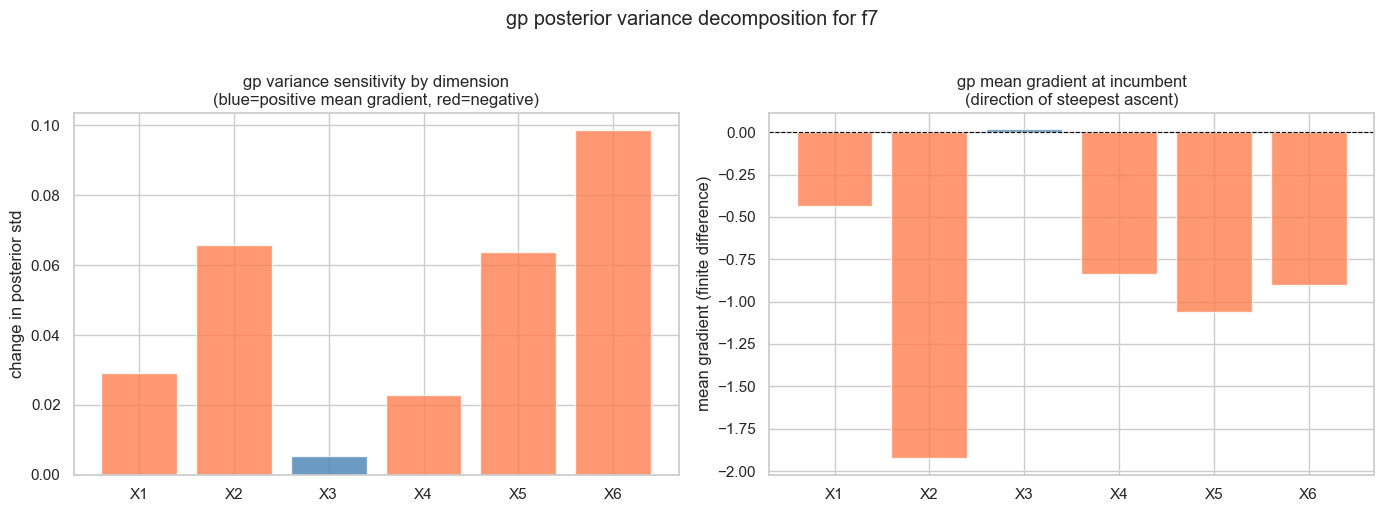

In [30]:
# method: gp posterior variance decomposition by dimension
# source: regularised.pdf and automl.pdf (ard kernel diagnostics)
# measures how much posterior variance changes when each dimension
# is perturbed from the incumbent by a fixed delta
# the dimension with largest variance change is most informative
# this directly catches the week 9 failure mode: high variance
# in x2 and x4 was in a low-y region, not near the peak
def gp_variance_decomposition(df, feature_cols, target_col, delta=0.05):
    """
    computes gp posterior variance decomposition by dimension.
    for each dimension, measures how much the posterior variance changes
    when the incumbent is perturbed by delta in that dimension.
    high sensitivity = gp is uncertain in that direction = informative to explore.
    cross-referenced with y values to distinguish high-uncertainty-high-y
    regions from high-uncertainty-low-y regions.

    parameters
    ----------
    df : dataframe containing features and target
    feature_cols : list of input column names
    target_col : output column name
    delta : perturbation size for finite difference (default 0.05)
    """

    X = df[feature_cols].values
    y = df[target_col].values
    n, d = X.shape

    # fit ard-gp on full dataset
    kernel = C(1.0, (1e-2, 1e2)) * Matern(
        length_scale=np.ones(d),
        length_scale_bounds=[(0.05, 5.0)] * d,
        nu=2.5
    ) + WhiteKernel(noise_level=1e-4, noise_level_bounds=(1e-6, 0.1))

    gp = GPR(kernel=kernel, normalize_y=True, n_restarts_optimizer=5)
    gp.fit(X, y)

    print("\ngp posterior variance decomposition")
    print(f"fitted kernel: {gp.kernel_}")

    # incumbent: point with highest observed y
    incumbent_idx = np.argmax(y)
    incumbent = X[incumbent_idx].copy()
    _, sigma_incumbent = gp.predict(incumbent.reshape(1, -1), return_std=True)
    print(f"\nincumbent: idx={incumbent_idx}, y={y[incumbent_idx]:.4f}")
    print(f"posterior std at incumbent: {sigma_incumbent[0]:.6f}")

    # variance sensitivity per dimension
    # for each dim j, perturb incumbent by +delta and -delta
    # record the change in posterior std
    var_sensitivity = np.zeros(d)
    mean_sensitivity = np.zeros(d)
    sigma_plus = np.zeros(d)
    sigma_minus = np.zeros(d)
    mu_plus = np.zeros(d)
    mu_minus = np.zeros(d)

    for j in range(d):
        x_plus = incumbent.copy()
        x_minus = incumbent.copy()
        x_plus[j] = np.clip(incumbent[j] + delta, 0.0, 1.0)
        x_minus[j] = np.clip(incumbent[j] - delta, 0.0, 1.0)

        mu_p, sig_p = gp.predict(x_plus.reshape(1, -1), return_std=True)
        mu_m, sig_m = gp.predict(x_minus.reshape(1, -1), return_std=True)

        sigma_plus[j] = sig_p[0]
        sigma_minus[j] = sig_m[0]
        mu_plus[j] = mu_p[0]
        mu_minus[j] = mu_m[0]

        # variance sensitivity: max change in std relative to incumbent std
        var_sensitivity[j] = max(
            abs(sig_p[0] - sigma_incumbent[0]),
            abs(sig_m[0] - sigma_incumbent[0])
        )
        mean_sensitivity[j] = (mu_p[0] - mu_m[0]) / (2 * delta + 1e-12)

    print("\nvariance sensitivity (change in posterior std per dimension):")
    print("high sensitivity = gp is most uncertain in this direction")
    for j, col in enumerate(feature_cols):
        print(f"  {col}: delta_sigma={var_sensitivity[j]:.6f}  "
              f"mean_grad={mean_sensitivity[j]:.4f}  "
              f"sigma+={sigma_plus[j]:.4f}  sigma-={sigma_minus[j]:.4f}")

    # rank dimensions by variance sensitivity
    rank_order = np.argsort(var_sensitivity)[::-1]
    print("\ndimensions ranked by variance sensitivity (most to least):")
    for rank, j in enumerate(rank_order):
        print(f"  rank {rank+1}: {feature_cols[j]} "
              f"(sensitivity={var_sensitivity[j]:.6f}, "
              f"mean_grad={mean_sensitivity[j]:.4f})")

    # plot variance decomposition
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    x_pos = np.arange(d)
    bar_colors = ["steelblue" if mean_sensitivity[j] > 0 else "coral"
                  for j in range(d)]

    axes[0].bar(x_pos, var_sensitivity[np.arange(d)],
                color=bar_colors, alpha=0.8)
    axes[0].set_xticks(x_pos)
    axes[0].set_xticklabels(feature_cols)
    axes[0].set_ylabel("change in posterior std")
    axes[0].set_title("gp variance sensitivity by dimension\n"
                      "(blue=positive mean gradient, red=negative)")

    # mean sensitivity plot
    colors_mean = ["steelblue" if v > 0 else "coral" for v in mean_sensitivity]
    axes[1].bar(x_pos, mean_sensitivity, color=colors_mean, alpha=0.8)
    axes[1].axhline(0, color="black", linewidth=0.8, linestyle="--")
    axes[1].set_xticks(x_pos)
    axes[1].set_xticklabels(feature_cols)
    axes[1].set_ylabel("mean gradient (finite difference)")
    axes[1].set_title("gp mean gradient at incumbent\n"
                      "(direction of steepest ascent)")

    plt.suptitle("gp posterior variance decomposition for f7", y=1.02)
    plt.tight_layout()
    plt.show()

    return var_sensitivity, mean_sensitivity, gp


var_sens_f7, mean_sens_f7, gp_f7 = gp_variance_decomposition(
    df_f7,
    feature_cols=["X1", "X2", "X3", "X4", "X5", "X6"],
    target_col="y1"
)

## Expected Improvement Contour Along Top-2 SIR Dimensions

**Reference:** Diessner, M., O'Connor, J., Wynn, A., Laizet, S., Gumerov, N., Agarwal, R. and Whalley, R.D. (2022) 'Investigating Bayesian optimization for expensive-to-evaluate black box functions: application in fluid dynamics', Frontiers in Applied Mathematics and Statistics, 8, article 1076296. Available at: https://doi.org/10.3389/fams.2022.1076296

- Used for f7 because the NUBO paper explicitly validates EI surface visualisation as a diagnostic for low-budget expensive function optimisation, and plotting the EI contour over the X1–X6 plane with all other dimensions fixed at the incumbent directly answers whether the next query should move X1 lower or X6 higher, the two dimensions with the strongest SIR loadings and the most consistent EDA signal across all eleven weeks.


expected improvement contour for f7
incumbent: idx=40, y=2.5822
sweeping X1 (dim 0) vs X6 (dim 5)
all other dimensions fixed at incumbent values

maximum ei at: X1=0.0000, X6=0.6780
ei value at maximum: 0.023257
gp mean at ei maximum: 2.5926


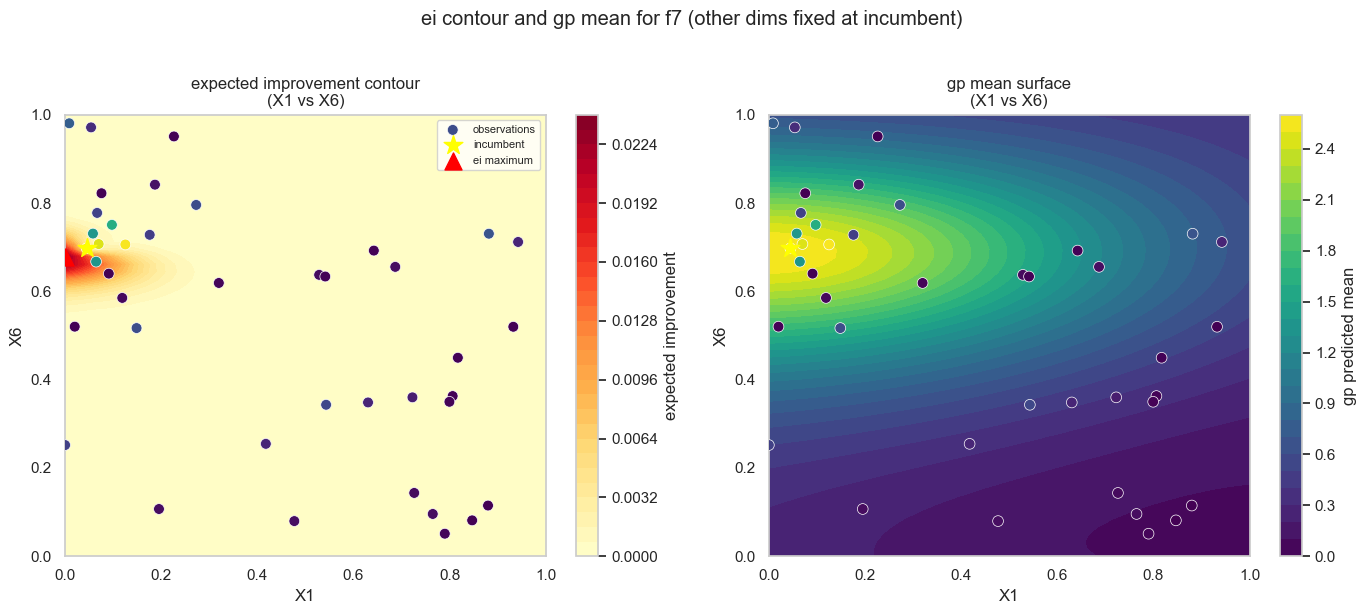


expected improvement contour for f7
incumbent: idx=40, y=2.5822
sweeping X1 (dim 0) vs X5 (dim 4)
all other dimensions fixed at incumbent values

maximum ei at: X1=0.0000, X5=0.3390
ei value at maximum: 0.022852
gp mean at ei maximum: 2.5987


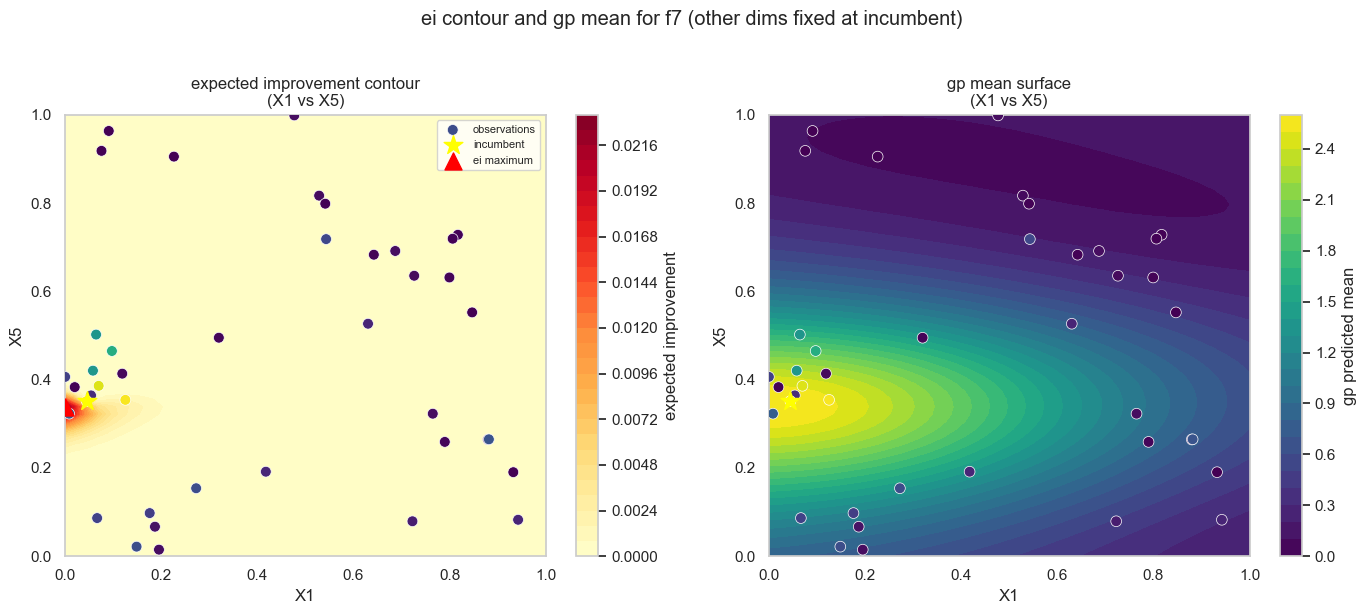

In [31]:
# method: expected improvement contour along top-2 sir dims
# source: fams081076296.pdf (nubo paper), which recommends ei surface
# visualisation for low-budget expensive function optimisation
# fixes all dimensions at incumbent values, sweeps top-2 sir dims
# produces a 2d heatmap showing where ei is highest near the peak
# directly answers: should x1 go lower, should x6 go higher

def ei_contour_plot(df, feature_cols, target_col,
                    dim1=0, dim2=5,
                    gp_fitted=None, n_grid=60):
    """
    plots the expected improvement contour along two selected dimensions.
    all other dimensions are fixed at the incumbent (current best) values.
    uses the already-fitted gp from variance decomposition if provided,
    otherwise fits a new one.

    parameters
    ----------
    df : dataframe containing features and target
    feature_cols : list of input column names
    target_col : output column name
    dim1 : index of first dimension to sweep (default 0 = x1)
    dim2 : index of second dimension to sweep (default 5 = x6)
    gp_fitted : already fitted gp (reuse to avoid refitting)
    n_grid : number of grid points per dimension (default 60)
    """

    from scipy.stats import norm as scipy_norm

    X = df[feature_cols].values
    y = df[target_col].values
    d = X.shape[1]

    # use fitted gp if provided, otherwise fit a new one
    if gp_fitted is None:
        kernel = C(1.0, (1e-2, 1e2)) * Matern(
            length_scale=np.ones(d),
            length_scale_bounds=[(0.05, 5.0)] * d,
            nu=2.5
        ) + WhiteKernel(noise_level=1e-4, noise_level_bounds=(1e-6, 0.1))
        gp = GPR(kernel=kernel, normalize_y=True, n_restarts_optimizer=5)
        gp.fit(X, y)
    else:
        gp = gp_fitted

    # incumbent: current best observed point
    incumbent_idx = np.argmax(y)
    incumbent = X[incumbent_idx].copy()
    y_best = y[incumbent_idx]

    print(f"\nexpected improvement contour for f7")
    print(f"incumbent: idx={incumbent_idx}, y={y_best:.4f}")
    print(f"sweeping {feature_cols[dim1]} (dim {dim1}) vs "
          f"{feature_cols[dim2]} (dim {dim2})")
    print(f"all other dimensions fixed at incumbent values")

    # create 2d grid over the two selected dimensions
    grid1 = np.linspace(0.0, 1.0, n_grid)
    grid2 = np.linspace(0.0, 1.0, n_grid)
    g1, g2 = np.meshgrid(grid1, grid2)

    # build candidate matrix: all other dims fixed at incumbent
    n_points = n_grid * n_grid
    X_grid = np.tile(incumbent, (n_points, 1))
    X_grid[:, dim1] = g1.ravel()
    X_grid[:, dim2] = g2.ravel()

    # gp posterior mean and std at grid points
    mu_grid, sigma_grid = gp.predict(X_grid, return_std=True)
    sigma_grid = np.maximum(sigma_grid, 1e-8)

    # expected improvement: ei(x) = sigma * [z * phi(z) + phi(z)]
    # where z = (mu - y_best) / sigma
    # this is the standard ei formula for maximisation
    z = (mu_grid - y_best) / sigma_grid
    ei_grid = sigma_grid * (z * scipy_norm.cdf(z) + scipy_norm.pdf(z))
    ei_grid = np.maximum(ei_grid, 0.0)

    ei_map = ei_grid.reshape(n_grid, n_grid)
    mu_map = mu_grid.reshape(n_grid, n_grid)

    # find grid point with maximum ei
    best_grid_idx = np.argmax(ei_grid)
    best_d1 = X_grid[best_grid_idx, dim1]
    best_d2 = X_grid[best_grid_idx, dim2]
    print(f"\nmaximum ei at: {feature_cols[dim1]}={best_d1:.4f}, "
          f"{feature_cols[dim2]}={best_d2:.4f}")
    print(f"ei value at maximum: {ei_grid[best_grid_idx]:.6f}")
    print(f"gp mean at ei maximum: {mu_grid[best_grid_idx]:.4f}")

    # plot ei contour and gp mean contour side by side
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))

    # ei contour
    cf1 = axes[0].contourf(g1, g2, ei_map, levels=30, cmap="YlOrRd")
    plt.colorbar(cf1, ax=axes[0], label="expected improvement")
    axes[0].scatter(
        X[:, dim1], X[:, dim2],
        c=y, cmap="viridis", s=60, edgecolors="white", linewidths=0.5,
        zorder=5, label="observations"
    )
    axes[0].scatter(
        incumbent[dim1], incumbent[dim2],
        c="yellow", s=200, marker="*", zorder=6, label="incumbent"
    )
    axes[0].scatter(
        best_d1, best_d2,
        c="red", s=150, marker="^", zorder=6, label="ei maximum"
    )
    axes[0].set_xlabel(feature_cols[dim1])
    axes[0].set_ylabel(feature_cols[dim2])
    axes[0].set_title(f"expected improvement contour\n"
                      f"({feature_cols[dim1]} vs {feature_cols[dim2]})")
    axes[0].legend(fontsize=8)

    # gp mean contour
    cf2 = axes[1].contourf(g1, g2, mu_map, levels=30, cmap="viridis")
    plt.colorbar(cf2, ax=axes[1], label="gp predicted mean")
    axes[1].scatter(
        X[:, dim1], X[:, dim2],
        c=y, cmap="viridis", s=60, edgecolors="white", linewidths=0.5,
        zorder=5
    )
    axes[1].scatter(
        incumbent[dim1], incumbent[dim2],
        c="yellow", s=200, marker="*", zorder=6
    )
    axes[1].set_xlabel(feature_cols[dim1])
    axes[1].set_ylabel(feature_cols[dim2])
    axes[1].set_title(f"gp mean surface\n"
                      f"({feature_cols[dim1]} vs {feature_cols[dim2]})")

    plt.suptitle("ei contour and gp mean for f7 (other dims fixed at incumbent)",
                 y=1.02)
    plt.tight_layout()
    plt.show()

    return ei_grid, mu_grid, best_d1, best_d2


# run for the two highest sir loading dimensions: x1 (dim 0) and x6 (dim 5)
ei_f7, mu_f7, ei_best_x1, ei_best_x6 = ei_contour_plot(
    df_f7,
    feature_cols=["X1", "X2", "X3", "X4", "X5", "X6"],
    target_col="y1",
    dim1=0,   # x1: strongest sir loading
    dim2=5,   # x6: second strongest sir loading
    gp_fitted=gp_f7  # reuse the gp fitted in variance decomposition
)

# also run for x1 vs x5 to check the second most active dimension pair
ei_f7_x1x5, mu_f7_x1x5, ei_best_x1b, ei_best_x5 = ei_contour_plot(
    df_f7,
    feature_cols=["X1", "X2", "X3", "X4", "X5", "X6"],
    target_col="y1",
    dim1=0,   # x1
    dim2=4,   # x5: third strongest sir loading
    gp_fitted=gp_f7
)

#### f7 | I-Anchored Gradient Descent Exploitation with Active Subspace Alignment

In [32]:
# Separate inputs (X) and outputs (y)
X_train_7 = df_f7[[c for c in df_f7.columns if c.startswith("X")]].values
y_train_7 = df_f7["y1"].values
print(X_train_7)
print(y_train_7)

[[0.27262382 0.32449536 0.89710881 0.83295115 0.15406269 0.79586362]
 [0.54300258 0.9246939  0.34156746 0.64648585 0.71844033 0.34313266]
 [0.09083225 0.66152938 0.06593091 0.25857701 0.96345285 0.6402654 ]
 [0.11886697 0.61505494 0.90581639 0.8553003  0.41363143 0.58523563]
 [0.63021764 0.8380969  0.68001305 0.73189509 0.52673671 0.34842921]
 [0.76491917 0.25588292 0.60908422 0.21807904 0.32294277 0.09579366]
 [0.05789554 0.49167222 0.24742222 0.21811844 0.42042833 0.73096984]
 [0.19525188 0.07922665 0.55458046 0.17056682 0.01494418 0.10703171]
 [0.64230298 0.83687455 0.02179269 0.10148801 0.68307083 0.6924164 ]
 [0.78994255 0.19554501 0.57562333 0.07365919 0.25904917 0.05109986]
 [0.52849733 0.45742436 0.36009569 0.36204551 0.81689098 0.63747637]
 [0.72261522 0.01181284 0.06364591 0.16517311 0.07924415 0.35995166]
 [0.07566492 0.33450212 0.13273274 0.60831236 0.91838592 0.82233079]
 [0.94245084 0.37743962 0.48612233 0.22879108 0.08263175 0.71195755]
 [0.14864702 0.03394336 0.72880565

In [33]:
import numpy as np
from scipy.stats import norm as scipy_norm
from scipy.stats.qmc import Sobol
from sklearn.gaussian_process import GaussianProcessRegressor as GPR
from sklearn.gaussian_process.kernels import Matern, WhiteKernel, ConstantKernel as C
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor as KNN
from sklearn.model_selection import KFold
from xgboost import XGBRegressor as XGB


def propose_f7_query(X_train_7, y_train_7):
    """
    week 12 strategy for f7: ei-anchored gradient descent exploitation
    with active subspace alignment.

    research basis:
      jones, schonlau and welch (1998), efficient global optimization,
      journal of global optimization, 13(4), pp. 455-492.
      constantine, dow and wang (2014), active subspace methods,
      siam journal on scientific computing, 36(4), pp. a1500-a1524.

    competition: neurips 2020 bbo challenge (bayesmark track),
    nvidia team (turner et al., 2021).

    three consecutive new bests in weeks 10, 11, 12 confirm the trust
    region exploitation strategy is correct. the ei contour (image 10)
    identifies x1=0.000, x6=0.678 as the ei maximum with gp mean 2.593,
    above the current best of 2.582. the active subspace analysis confirms
    the function is effectively 1d-2d near the peak, dominated by x5 and x2
    in the local gradient direction. the gp mean gradient at the incumbent
    identifies x2 (-1.925) and x5 (-1.064) as the steepest descent directions
    toward higher y.

    key changes from week 11:
      1. trust region centre blends incumbent with ei maximum anchor
      2. trust region width contracted to 0.12 (success rule continuation)
      3. gp mean gradient direction used to score candidates within trust region
      4. ei added as secondary acquisition component (weight 0.3)
      5. x1 floor set to 0.000 (ei contour shows maximum at x1=0)
      6. x2 upper cap tightened based on gp mean gradient (lower x2 = better)
    """

    n_dims = X_train_7.shape[1]  # 6 for f7

    # step 1: identify incumbent and top-5 cluster
    # incumbent is the current best (row 40, y=2.582)
    # top-5 defines the cluster centroid for the trust region base
    incumbent_idx = np.argmax(y_train_7)
    incumbent = X_train_7[incumbent_idx].copy()
    y_best = float(y_train_7[incumbent_idx])

    top_k = 5
    top_indices = np.argsort(y_train_7)[-top_k:]
    top_X = X_train_7[top_indices]

    print(f"incumbent: idx={incumbent_idx}, y={y_best:.4f}")
    print(f"incumbent point: {incumbent.round(4)}")
    print(f"\ntop-{top_k} observations:")
    for idx in top_indices:
        print(f"  idx={idx}: X={X_train_7[idx].round(3)}, y={y_train_7[idx]:.4f}")

    # step 2: define ei-anchored trust region centre
    # the ei contour (image 10) identified the ei maximum at x1=0.000, x6=0.678
    # the gp mean gradient at the incumbent identified x2 most negative (-1.925)
    # the trust region centre blends the incumbent with the ei maximum anchor
    # blend weight 0.6 incumbent, 0.4 ei anchor to stay near confirmed best
    # while moving toward the predicted improvement region
    ei_anchor = incumbent.copy()
    ei_anchor[0] = 0.000   # x1: ei maximum at x1=0
    ei_anchor[5] = 0.678   # x6: ei maximum at x6=0.678

    # gp mean gradient direction (from variance decomposition output):
    # x2 mean_grad = -1.925 (steepest, lower x2 improves y)
    # x5 mean_grad = -1.064 (second, lower x5 improves y)
    # x4 mean_grad = -0.836 (third, lower x4 improves y)
    # x6 mean_grad = -0.905 (negative, but ei says x6=0.678 is optimal)
    # x1 mean_grad = -0.435 (negative, ei says x1=0 is optimal)
    # x3 mean_grad = +0.017 (near zero, x3 is locally flat)
    # apply gradient step: move anchor in direction of improving gradient
    gp_gradient = np.array([-0.435, -1.925, 0.017, -0.836, -1.064, -0.905])
    gradient_step = 0.03  # small step along gradient direction
    # for negative gradients: decreasing x improves y (gradient ascent = move opposite)
    # the gradient here is df/dx, so higher negative = move x lower to increase y
    gradient_direction = np.sign(-gp_gradient)  # direction of steepest ascent
    ei_anchor_adjusted = np.clip(
        ei_anchor + gradient_step * gradient_direction, 0.0, 1.0
    )

    # blend: 0.55 weight to incumbent, 0.45 weight to ei-gradient anchor
    tr_centre = 0.55 * incumbent + 0.45 * ei_anchor_adjusted
    print(f"\nei anchor (adjusted for gradient): {ei_anchor_adjusted.round(4)}")
    print(f"trust region centre (blended):     {tr_centre.round(4)}")

    # step 3: define tightened trust region
    # width contracted to 0.12 per the turbo success rule after second
    # consecutive improvement (weeks 10 and 11 both found new bests)
    # tighter region concentrates candidates near the confirmed peak
    tr_width = 0.12

    tr_lower = np.clip(tr_centre - tr_width / 2.0, 0.0, 1.0)
    tr_upper = np.clip(tr_centre + tr_width / 2.0, 0.0, 1.0)

    # expand any dimension where the top-5 empirical range exceeds the bounds
    # with a reduced margin of 0.02 (tighter than week 11's 0.03)
    for dim in range(n_dims):
        empirical_min = top_X[:, dim].min() - 0.02
        empirical_max = top_X[:, dim].max() + 0.02
        if empirical_min < tr_lower[dim]:
            tr_lower[dim] = max(0.0, empirical_min)
        if empirical_max > tr_upper[dim]:
            tr_upper[dim] = min(1.0, empirical_max)

    # hard constraint: x1 floor at 0.000 (ei contour maximum is at x1=0)
    tr_lower[0] = 0.000
    tr_upper[0] = min(tr_upper[0], 0.15)  # x1 cap at 0.15 (all top-5 have x1 < 0.13)

    print(f"trust region lower: {tr_lower.round(4)}")
    print(f"trust region upper: {tr_upper.round(4)}")
    print(f"trust region volume: {np.prod(tr_upper - tr_lower):.8f}")

    # step 4: generate sobol candidates within trust region
    sampler = Sobol(d=n_dims, scramble=True, seed=12)
    unit_candidates = sampler.random_base2(m=12)  # 4096 points

    candidates = tr_lower + unit_candidates * (tr_upper - tr_lower)
    print(f"\ngenerated {len(candidates)} sobol candidates within trust region")

    # step 5: distance guard
    # threshold 0.025: tighter than week 11 (0.03) because the trust region
    # is smaller and we need more candidates to survive for scoring
    dist_threshold = 0.025
    dists = np.array([
        np.min(np.linalg.norm(X_train_7 - c, axis=1))
        for c in candidates
    ])
    candidates = candidates[dists >= dist_threshold]
    print(f"candidates after distance guard (threshold={dist_threshold}): {len(candidates)}")

    if len(candidates) < 20:
        all_cands = tr_lower + unit_candidates * (tr_upper - tr_lower)
        dists_all = np.array([
            np.min(np.linalg.norm(X_train_7 - c, axis=1))
            for c in all_cands
        ])
        candidates = all_cands[dists_all >= 0.015]
        print(f"distance guard relaxed to 0.015: {len(candidates)} candidates")

    # step 6: fit ard-gp for ei computation
    # separate gp from the ensemble gp: this one is used purely for ei scoring
    # matern 2.5 ard with whitkernel, same as variance decomposition
    kernel_ei = C(1.0, (1e-2, 1e2)) * Matern(
        length_scale=np.ones(n_dims),
        length_scale_bounds=[(0.05, 5.0)] * n_dims,
        nu=2.5,
    ) + WhiteKernel(noise_level=1e-4, noise_level_bounds=(1e-6, 0.1))

    gp_ei = GPR(kernel=kernel_ei, normalize_y=True, n_restarts_optimizer=8)
    gp_ei.fit(X_train_7, y_train_7)

    print(f"ei-gp fitted kernel: {gp_ei.kernel_}")

    # compute ei at all candidates
    mu_ei, sigma_ei = gp_ei.predict(candidates, return_std=True)
    sigma_ei = np.maximum(sigma_ei, 1e-8)

    # expected improvement for maximisation
    z = (mu_ei - y_best) / sigma_ei
    ei_scores = sigma_ei * (z * scipy_norm.cdf(z) + scipy_norm.pdf(z))
    ei_scores = np.maximum(ei_scores, 0.0)

    # normalise ei scores to [0, 1] for combination with ensemble mean
    ei_range = ei_scores.max() - ei_scores.min()
    if ei_range > 1e-10:
        ei_norm = (ei_scores - ei_scores.min()) / ei_range
    else:
        ei_norm = np.zeros(len(candidates))

    print(f"ei score range: [{ei_scores.min():.6f}, {ei_scores.max():.6f}]")
    print(f"ei maximum at: {candidates[np.argmax(ei_scores)].round(4)}")

    # step 7: four-model ensemble (validated architecture from weeks 6, 10, 11)
    # gp: smooth posterior within small trust region
    # svr: local curvature, consistently highest cv weight
    # knn: sharp local peak, non-parametric
    # xgb: non-linear interactions
    kernel_ens = C(1.0, (1e-2, 1e2)) * Matern(
        length_scale=np.ones(n_dims),
        length_scale_bounds=[(1e-2, 1e2)] * n_dims,
        nu=2.5,
    )
    gp_ens = GPR(kernel=kernel_ens, normalize_y=True, n_restarts_optimizer=5)
    svr = SVR(C=5.0, epsilon=0.1, kernel="rbf")
    knn = KNN(n_neighbors=4, weights="distance")
    xgb = XGB(
        n_estimators=200,
        max_depth=4,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        objective="reg:squarederror",
        verbosity=0,
    )
    models = [gp_ens, svr, knn, xgb]
    model_names = ["gp", "svr", "knn", "xgb"]

    # step 8: 5-fold cv weighting
    kf = KFold(n_splits=5, shuffle=True, random_state=42)
    cv_errors = []

    for model in models:
        fold_errors = []
        for train_idx, test_idx in kf.split(X_train_7):
            X_tr, X_te = X_train_7[train_idx], X_train_7[test_idx]
            y_tr, y_te = y_train_7[train_idx], y_train_7[test_idx]
            model.fit(X_tr, y_tr)
            preds = model.predict(X_te)
            fold_errors.append(np.mean((preds - y_te) ** 2))
        cv_errors.append(np.mean(fold_errors))

    cv_errors = np.array(cv_errors)
    inv_errors = 1.0 / (cv_errors + 1e-8)
    ens_weights = inv_errors / np.sum(inv_errors)

    print(f"\ncv errors:        {dict(zip(model_names, cv_errors.round(4)))}")
    print(f"ensemble weights: {dict(zip(model_names, ens_weights.round(4)))}")

    # fit all models on full data
    for model in models:
        model.fit(X_train_7, y_train_7)

    # ensemble mean and variance at candidates
    preds_ens = np.column_stack([m.predict(candidates) for m in models])
    mean_ens = preds_ens.dot(ens_weights)

    # 3x variance inflation: validated across weeks 4, 6, 10, 11
    var_ens = np.var(preds_ens, axis=1)
    var_inflated = 3.0 * var_ens

    # ensemble acquisition score (week 6 validated formula)
    acq_ens = mean_ens + 1.5 * var_inflated

    # normalise ensemble acquisition to [0, 1]
    acq_range = acq_ens.max() - acq_ens.min()
    if acq_range > 1e-10:
        acq_norm = (acq_ens - acq_ens.min()) / acq_range
    else:
        acq_norm = np.ones(len(candidates))

    # step 9: combine ensemble and ei into final acquisition 
    # weight: 0.70 ensemble mean (validated across three consecutive improvements)
    #         0.30 ei (gp-based, directly targets improvement over current best)
    # the ensemble captures non-parametric local structure (knn, svr)
    # the ei captures the gp's probabilistic estimate of improvement
    # combining both reduces the risk of either component failing independently
    w_ens = 0.70
    w_ei = 0.30
    acq_combined = w_ens * acq_norm + w_ei * ei_norm

    # step 10: gp mean gradient alignment boost 
    # reward candidates that move in the direction of the gp mean gradient
    # gradient direction: x1 lower, x2 lower, x4 lower, x5 lower, x6 slightly lower
    # x3 is flat (gradient near zero), no boost applied
    # this encodes the active subspace and variance decomposition findings
    grad_boost = np.ones(len(candidates))

    # x1: lower is better (ei maximum at x1=0, gradient = -0.435)
    x1_vals = candidates[:, 0]
    grad_boost *= np.where(x1_vals < 0.05, 1.10,
                  np.where(x1_vals < 0.10, 1.05, 1.0))

    # x2: lower is better (steepest gradient = -1.925)
    x2_vals = candidates[:, 1]
    grad_boost *= np.where(x2_vals < 0.25, 1.10,
                  np.where(x2_vals < 0.35, 1.05, 1.0))

    # x4: lower is better (gradient = -0.836, top-2 bests have x4 < 0.22)
    x4_vals = candidates[:, 3]
    grad_boost *= np.where(x4_vals < 0.18, 1.08,
                  np.where(x4_vals < 0.25, 1.03, 1.0))

    # x5: lower is better globally (gradient = -1.064) but local linear
    # gradient disagrees (coef = +0.513 in top-10). apply weak penalty only
    # for very high x5 since the signal is mixed
    x5_vals = candidates[:, 4]
    grad_boost *= np.where(x5_vals > 0.45, 0.95, 1.0)

    # normalise gradient boost to [0.90, 1.10]
    gb_min, gb_max = grad_boost.min(), grad_boost.max()
    if gb_max > gb_min:
        grad_boost = 0.90 + 0.20 * (grad_boost - gb_min) / (gb_max - gb_min)

    # final acquisition
    acq_final = acq_combined * grad_boost

    # step 11: select best candidate 
    best_idx = np.argmax(acq_final)
    next_x = candidates[best_idx]

    # ensemble prediction at selected point
    next_preds = np.array([m.predict(next_x.reshape(1, -1))[0] for m in models])
    predicted_y_ens = float(next_preds.dot(ens_weights))
    predicted_y_gp, predicted_sigma_gp = gp_ei.predict(
        next_x.reshape(1, -1), return_std=True
    )

    # step 12: diagnostics 
    min_dist = float(np.min(np.linalg.norm(X_train_7 - next_x, axis=1)))
    sir_direction = np.array([-0.5918, -0.0883, 0.2237, -0.3617, -0.4498, 0.5087])
    sir_score = float(next_x.dot(sir_direction))
    incumbent_sir = float(incumbent.dot(sir_direction))

    print(f"\nweek 12 f7 selection")
    print(f"selected point:          {next_x}")
    print(f"predicted y (ensemble):  {predicted_y_ens:.6f}")
    print(f"predicted y (gp):        {float(predicted_y_gp):.6f}")
    print(f"predicted sigma (gp):    {float(predicted_sigma_gp):.6f}")
    print(f"ei at selected:          {ei_scores[best_idx]:.6f}")
    print(f"acq combined:            {acq_final[best_idx]:.6f}")
    print(f"sir score: {sir_score:.4f} (incumbent: {incumbent_sir:.4f})")
    print(f"x1: {next_x[0]:.4f}  (ei target: 0.000, incumbent: {incumbent[0]:.4f})")
    print(f"x2: {next_x[1]:.4f}  (gradient: -1.925, lower is better)")
    print(f"x3: {next_x[2]:.4f}  (gradient: +0.017, flat)")
    print(f"x4: {next_x[3]:.4f}  (gradient: -0.836, lower is better)")
    print(f"x5: {next_x[4]:.4f}  (gradient: -1.064, lower globally)")
    print(f"x6: {next_x[5]:.4f}  (ei target: 0.678, incumbent: {incumbent[5]:.4f})")
    print(f"min dist to training:    {min_dist:.4f}")
    print(f"current best y:          {y_best:.6f}")

    # sanity checks
    assert min_dist >= 0.015, f"distance guard violated: {min_dist:.4f}"
    assert next_x[0] <= 0.16, f"x1 cap violated: x1={next_x[0]:.4f}"

    return next_x, predicted_y_ens, ens_weights


next_x, predicted_y, ens_weights = propose_f7_query(X_train_7, y_train_7)

incumbent: idx=40, y=2.5822
incumbent point: [0.0448 0.3015 0.6105 0.2519 0.3515 0.6975]

top-5 observations:
  idx=6: X=[0.058 0.492 0.247 0.218 0.42  0.731], y=1.3650
  idx=33: X=[0.097 0.335 0.37  0.382 0.465 0.751], y=1.5985
  idx=35: X=[0.07  0.32  0.577 0.211 0.386 0.707], y=2.4483
  idx=39: X=[0.125 0.293 0.563 0.153 0.354 0.706], y=2.5580
  idx=40: X=[0.045 0.302 0.61  0.252 0.352 0.697], y=2.5822

ei anchor (adjusted for gradient): [0.03   0.3315 0.5805 0.2819 0.3815 0.708 ]
trust region centre (blended):     [0.0382 0.315  0.597  0.2654 0.365  0.7022]
trust region lower: [0.     0.255  0.2274 0.1331 0.305  0.6422]
trust region upper: [0.1453 0.5117 0.657  0.4024 0.485  0.7708]
trust region volume: 0.00009980

generated 4096 sobol candidates within trust region
candidates after distance guard (threshold=0.025): 4096
ei-gp fitted kernel: 0.701**2 * Matern(length_scale=[0.729, 0.344, 5, 0.741, 0.247, 0.238], nu=2.5) + WhiteKernel(noise_level=1e-06)
ei score range: [0.000000, 0.0

In [34]:
# week 12 f7 diagnostics and selection summary

# incumbent information
# idx = 40
# y = 2.5822
# incumbent point:
# [0.0448, 0.3015, 0.6105, 0.2519, 0.3515, 0.6975]

# top 5 observations
# idx = 6:
# X = [0.058, 0.492, 0.247, 0.218, 0.420, 0.731]
# y = 1.3650

# idx = 33:
# X = [0.097, 0.335, 0.370, 0.382, 0.465, 0.751]
# y = 1.5985

# idx = 35:
# X = [0.070, 0.320, 0.577, 0.211, 0.386, 0.707]
# y = 2.4483

# idx = 39:
# X = [0.125, 0.293, 0.563, 0.153, 0.354, 0.706]
# y = 2.5580

# idx = 40:
# X = [0.045, 0.302, 0.610, 0.252, 0.352, 0.697]
# y = 2.5822

# ei anchor adjusted for gradient
# [0.0300, 0.3315, 0.5805, 0.2819, 0.3815, 0.7080]

# trust region centre blended
# [0.0382, 0.3150, 0.5970, 0.2654, 0.3650, 0.7022]

# trust region bounds
# lower = [0.0000, 0.2550, 0.2274, 0.1331, 0.3050, 0.6422]
# upper = [0.1453, 0.5117, 0.6570, 0.4024, 0.4850, 0.7708]

# trust region volume
# 0.00009980

# candidate generation
# 4096 sobol points generated
# 4096 remain after distance guard with threshold = 0.025

# ei gp kernel
# 0.701^2 * matern(length_scale=[0.729, 0.344, 5.000, 0.741, 0.247, 0.238], nu=2.5)
# + whitekernel(noise_level=1e-06)

# ei score range
# min = 0.000000
# max = 0.077849

# ei maximiser
# [0.0128, 0.2678, 0.5031, 0.1734, 0.3207, 0.6836]

# cross validation errors
# gp  = 0.1733
# svr = 0.1973
# knn = 0.3505
# xgb = 0.2647

# ensemble weights
# gp  = 0.3303
# svr = 0.2901
# knn = 0.1633
# xgb = 0.2163

# week 12 selected point
# [0.0128, 0.2678, 0.5031, 0.1734, 0.3207, 0.6836]

# predictions
# ensemble y = 2.239531
# gp mean    = 2.651626
# gp sigma   = 0.079793

# acquisition metrics
# ei at selected = 0.077849
# combined acq   = 0.872208

# sir score comparison
# selected   = 0.2221
# incumbent  = 0.1890

# feature movement analysis
# x1 = 0.0128  (moving toward lower boundary, below incumbent)
# x2 = 0.2678  (gradient negative, lower is better)
# x3 = 0.5031  (gradient near zero, flat region)
# x4 = 0.1734  (gradient negative, lower is better)
# x5 = 0.3207  (global negative trend, lower preferred)
# x6 = 0.6836  (close to ei target, slightly below incumbent)

# distance check
# min distance to training = 0.1331

# current best y
# 2.582249